This script evaluates grid alignment, writes a vrt in order to build a stitched tif, producing rasters approximately 50gb in size. 
it produces some exploratory map figures, used in the thesis proposal. it also evaluates histograms of some of the bands to check stable convergence on useable/realistic data. Lastly, it compares the density of information for RMSE vs amplitude and RMSE vs mean to show that there is sufficient variation in the data to produce meaningful analyses. 

Look at file alignment: Expect 1 unique grid signature with this metadata

('EPSG:26911', 10.0, -10.0, 527740.0, 4815410.0, 10435, 7857)

In [ ]:
#Evaluate grids across downloads; check for alignment between mosaics and template grid

import rasterio
from collections import Counter
#"C:/NCA_DATA/S2_Harmonics_mosaicked/S2SR_Harmonics_2018_mosaic.tif","C:/NCA_DATA/S2_Harmonics_mosaicked/S2SR_Harmonics_2019_mosaic.tif", "C:/NCA_DATA/S2_Harmonics_mosaicked/S2SR_Harmonics_2020_mosaic.tif", "C:/NCA_DATA/S2_SR_monthly_median_mosaicked/S2_SR_2018_01_median_mosaic.tif","C:/NCA_DATA/S2_SR_monthly_median_mosaicked/S2_SR_2018_06_median_mosaic.tif","C:/NCA_DATA/S2_SR_monthly_median_mosaicked/S2_SR_2019_01_median_mosaic.tif", 
tile_paths = ["C:/NCA_DATA/templates/grid_template_10m_26911_uint8.tif", 
              "C:/NCA_DATA/S2_Harmonics_vrt/S2SR_Harmonics_2025_4th_amp_phase_masked.tif",
              "C:/NCA_DATA/Ancillary_Data/POLARIS_26911_10m_mosaic.tif",
              "C:/NCA_DATA/Ancillary_Data/USGS3DEP_topo_26911_10m.tif"]

def grid_signature(path):
    with rasterio.open(path) as ds:
        tr = ds.transform
        return (str(ds.crs), tr.a, tr.e, tr.c, tr.f, ds.width, ds.height)

sigs = [grid_signature(p) for p in tile_paths]
counts = Counter(sigs)

print("Unique grid signatures:", len(counts))
for sig, n in counts.most_common(5):
    print(n, sig)

Unique grid signatures: 1
4 ('EPSG:26911', 10.0, -10.0, 527740.0, 4815410.0, 10435, 7857)


In [2]:
#Create a valid template raster now that we know grids are aligned
#This allows for rasterization of LTDL and SSURGO data with this target grid

import numpy as np
import rasterio

src_path = r"C:/NCA_DATA/S2_SR_monthly_median_mosaicked/S2_SR_2018_01_median_mosaic.tif"
out_path = r"C:/NCA_DATA/templates/grid_template_10m_26911_uint8.tif"

with rasterio.open(src_path) as src:
    profile = src.profile.copy()
    profile.update(
        count=1,
        dtype="uint8",
        nodata=0,
        compress="deflate",
        predictor=2,
        tiled=True
    )

    data = np.zeros((src.height, src.width), dtype=np.uint8)

    with rasterio.open(out_path, "w", **profile) as dst:
        dst.write(data, 1)

print("Wrote:", out_path)


Wrote: C:/NCA_DATA/templates/grid_template_10m_26911_uint8.tif


In [ ]:
#Audit the template file metadata

import rasterio
from rasterio.enums import Resampling
from pprint import pprint

template_path = r"C:/NCA_DATA/templates/grid_template_10m_26911_uint8.tif"

with rasterio.open(template_path) as ds:
    print("---- BASIC INFO ----")
    print("Driver:", ds.driver)
    print("Width, Height:", ds.width, ds.height)
    print("Count (bands):", ds.count)
    print("Dtype:", ds.dtypes)
    print("CRS:", ds.crs)
    print("CRS (WKT):")
    print(ds.crs.to_wkt())
    print()

    print("---- TRANSFORM ----")
    print("Affine:", ds.transform)
    print("Pixel size X:", ds.transform.a)
    print("Pixel size Y:", ds.transform.e)
    print("Origin X (upper-left):", ds.transform.c)
    print("Origin Y (upper-left):", ds.transform.f)
    print()

    print("---- BOUNDS ----")
    print("Bounds:", ds.bounds)
    print()

    print("---- NODATA ----")
    print("Nodata:", ds.nodata)
    print()

    print("---- TILING / BLOCK INFO ----")
    print("Tiled:", ds.is_tiled)
    print("Block shapes:", ds.block_shapes)
    print()

    print("---- COMPRESSION ----")
    pprint(ds.profile)
    print()

    print("---- BAND METADATA ----")
    for i in range(1, ds.count + 1):
        print(f"Band {i} description:", ds.descriptions[i-1])
        print(f"Band {i} tags:", ds.tags(i))
        print()


---- BASIC INFO ----
Driver: GTiff
Width, Height: 10435 7857
Count (bands): 1
Dtype: ('uint8',)
CRS: EPSG:26911
CRS (WKT):
PROJCS["NAD83 / UTM zone 11N",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4269"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-117],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","26911"]]

---- TRANSFORM ----
Affine: | 10.00, 0.00, 527740.00|
| 0.00,-10.00, 4815410.00|
| 0.00, 0.00, 1.00|
Pixel size X: 10.0
Pixel size Y: -10.0
Origin X (upper-left): 527740.0
Origin Y (upper-left): 4815410.0

---- BOUNDS ----
Bounds: BoundingBox(left=527740.0, b

In [ ]:
import numpy as np
import rasterio
from pathlib import Path

out_vrt = Path(r"C:\NCA_DATA\S2_Harmonics_vrt\S2SR_Harmonics_2018_4th.vrt")

with rasterio.open(out_vrt) as src:
    band1 = src.read(1, masked=True)

print("shape:", band1.shape)
print("dtype:", band1.dtype)
print("masked:", np.ma.is_masked(band1))
print("min:", band1.min())
print("max:", band1.max())
print("mean:", band1.mean())
print("std:", band1.std())

vals = band1.compressed()
print("unique sample count:", len(np.unique(vals[:100000])))

In [19]:
#Print beta_0 maps

import numpy as np
import rasterio
import matplotlib.pyplot as plt
from pathlib import Path

out_vrt = r"C:\NCA_DATA\S2_Harmonics_vrt\S2SR_Harmonics_2024_4th.vrt"
fig_dir = Path(r"C:\NCA_DATA\Figures\2024\Intercept")
fig_dir.mkdir(exist_ok=True)

band_names = [
    "B2", "B3", "B4", "B5", "B6", "B7", "B8", "B8A", "B11", "B12", 
    "NDVI", "NDMI", "NDRE", "BSI", "NBR2"
]

index_names = {"NDVI", "NDMI", "NDRE", "BSI", "NBR2"}

with rasterio.open(out_vrt) as src:

    for i, band_name in enumerate(band_names, start=1):
        data = src.read(i).astype("float32")
        data = np.ma.masked_where(data == -32768, data)

        vals = data.compressed()
        if len(vals) == 0:
            print(f"Skipped {band_name}: no valid pixels")
            continue

        p2, p98 = np.percentile(vals, [2, 98])

        if band_name in index_names:
            title = f"2024 {band_name} Annual Mean Index ($\\beta_0$)"
        else:
            title = f"2024 {band_name} Annual Mean Reflectance ($\\beta_0$)"

        plt.figure(figsize=(12, 8))
        plt.imshow(data, cmap="viridis", vmin=p2, vmax=p98)
        plt.colorbar()
        plt.title(title)
        plt.axis("off")

        fname = (
            title
            .replace("$\\beta_0$", "beta0")
            .replace(" ", "_")
        )
        outfile = fig_dir / f"{fname}.png"

        plt.savefig(outfile, dpi=300, bbox_inches="tight")
        plt.close()

        print(f"Saved: {outfile}")
#runtime ~ 25mins

Saved: C:\NCA_DATA\Figures\2024\Intercept\2024_B2_Annual_Mean_Reflectance_(beta0).png
Saved: C:\NCA_DATA\Figures\2024\Intercept\2024_B3_Annual_Mean_Reflectance_(beta0).png
Saved: C:\NCA_DATA\Figures\2024\Intercept\2024_B4_Annual_Mean_Reflectance_(beta0).png
Saved: C:\NCA_DATA\Figures\2024\Intercept\2024_B5_Annual_Mean_Reflectance_(beta0).png
Saved: C:\NCA_DATA\Figures\2024\Intercept\2024_B6_Annual_Mean_Reflectance_(beta0).png
Saved: C:\NCA_DATA\Figures\2024\Intercept\2024_B7_Annual_Mean_Reflectance_(beta0).png
Saved: C:\NCA_DATA\Figures\2024\Intercept\2024_B8_Annual_Mean_Reflectance_(beta0).png
Saved: C:\NCA_DATA\Figures\2024\Intercept\2024_B8A_Annual_Mean_Reflectance_(beta0).png
Saved: C:\NCA_DATA\Figures\2024\Intercept\2024_B11_Annual_Mean_Reflectance_(beta0).png
Saved: C:\NCA_DATA\Figures\2024\Intercept\2024_B12_Annual_Mean_Reflectance_(beta0).png
Saved: C:\NCA_DATA\Figures\2024\Intercept\2024_NDVI_Annual_Mean_Index_(beta0).png
Saved: C:\NCA_DATA\Figures\2024\Intercept\2024_NDMI_Ann

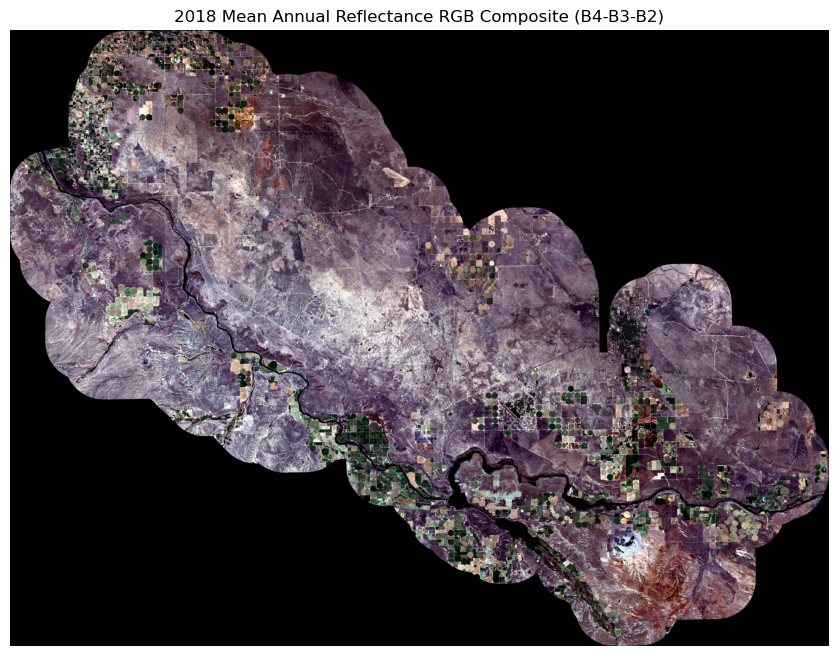

Saved: C:\NCA_DATA\Figures\2018_Mean_Annual_Reflectance_RGB_Composite_B4_B3_B2.png


In [1]:
#RGB true color approx with percentile stretch
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from pathlib import Path

out_vrt = r"C:\NCA_DATA\S2_Harmonics_vrt\S2SR_Harmonics_2018_4th.vrt"
fig_dir = Path(r"C:\NCA_DATA\Figures")
fig_dir.mkdir(exist_ok=True)

with rasterio.open(out_vrt) as src:
    b2 = src.read(1).astype("float32")  # constant_B2
    b3 = src.read(2).astype("float32")  # constant_B3
    b4 = src.read(3).astype("float32")  # constant_B4

# mask nodata
mask = (b2 == -32768) | (b3 == -32768) | (b4 == -32768)

b2 = np.ma.masked_where(mask, b2)
b3 = np.ma.masked_where(mask, b3)
b4 = np.ma.masked_where(mask, b4)

# robust scaling function
def stretch_band(arr, p_low=2, p_high=98):
    vals = arr.compressed()
    lo, hi = np.percentile(vals, [p_low, p_high])
    stretched = (arr - lo) / (hi - lo)
    return np.clip(stretched, 0, 1)

r = stretch_band(b4)
g = stretch_band(b3)
b = stretch_band(b2)

rgb = np.dstack([r, g, b])

title = "2018 Mean Annual Reflectance RGB Composite (B4-B3-B2)"
outfile = fig_dir / "2018_Mean_Annual_Reflectance_RGB_Composite_B4_B3_B2.png"

plt.figure(figsize=(12, 8))
plt.imshow(rgb)
plt.title(title)
plt.axis("off")
plt.savefig(outfile, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print(f"Saved: {outfile}")

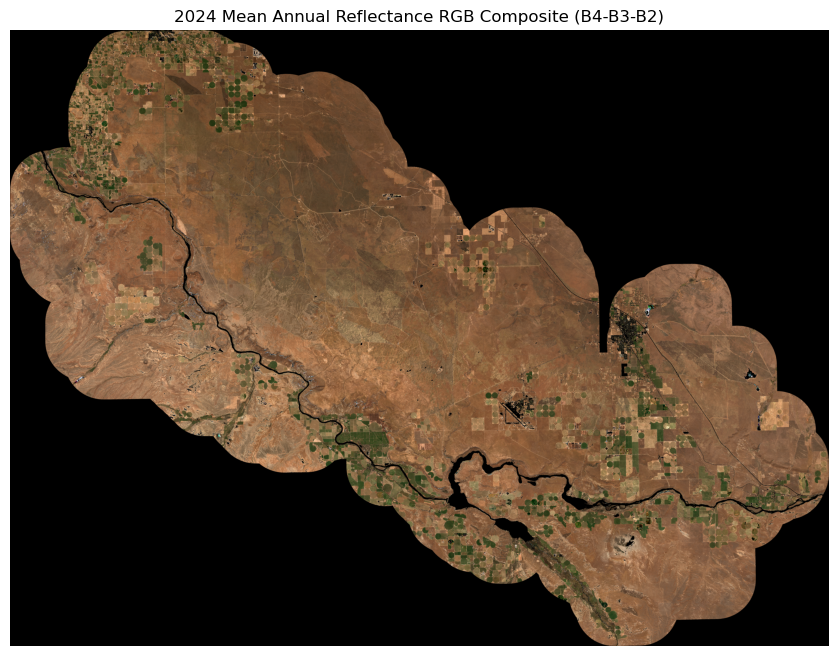

Saved: C:\NCA_DATA\Figures\2024\2024_Mean_Annual_Reflectance_RGB_Composite_B4_B3_B2.png


In [23]:
# RGB true color approx using fixed reflectance scaling instead of percentile
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from pathlib import Path

out_vrt = r"C:\NCA_DATA\S2_Harmonics_vrt\S2SR_Harmonics_2024_4th.vrt"
fig_dir = Path(r"C:\NCA_DATA\Figures\2024")
fig_dir.mkdir(exist_ok=True)

with rasterio.open(out_vrt) as src:
    b2 = src.read(1).astype("float32")  # constant_B2
    b3 = src.read(2).astype("float32")  # constant_B3
    b4 = src.read(3).astype("float32")  # constant_B4
    nodata = src.nodata

# mask nodata and obvious nonphysical values
mask = (
    (b2 == nodata) | (b3 == nodata) | (b4 == nodata) |
    (b2 < 0) | (b3 < 0) | (b4 < 0) |
    (b2 > 1) | (b3 > 1) | (b4 > 1)
)

b2 = np.ma.masked_where(mask, b2)
b3 = np.ma.masked_where(mask, b3)
b4 = np.ma.masked_where(mask, b4)

def fixed_stretch(arr, lo=0.02, hi=0.25):
    stretched = (arr - lo) / (hi - lo)
    return np.clip(stretched, 0, 1)

r = fixed_stretch(b4, 0.02, 0.25)
g = fixed_stretch(b3, 0.02, 0.25)
b = fixed_stretch(b2, 0.02, 0.25)

rgb = np.dstack([r, g, b])

title = "2024 Mean Annual Reflectance RGB Composite (B4-B3-B2)"
outfile = fig_dir / "2024_Mean_Annual_Reflectance_RGB_Composite_B4_B3_B2.png"

plt.figure(figsize=(12, 8))
plt.imshow(rgb)
plt.title(title)
plt.axis("off")
plt.savefig(outfile, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print(f"Saved: {outfile}")
#runtime ~ 5mins

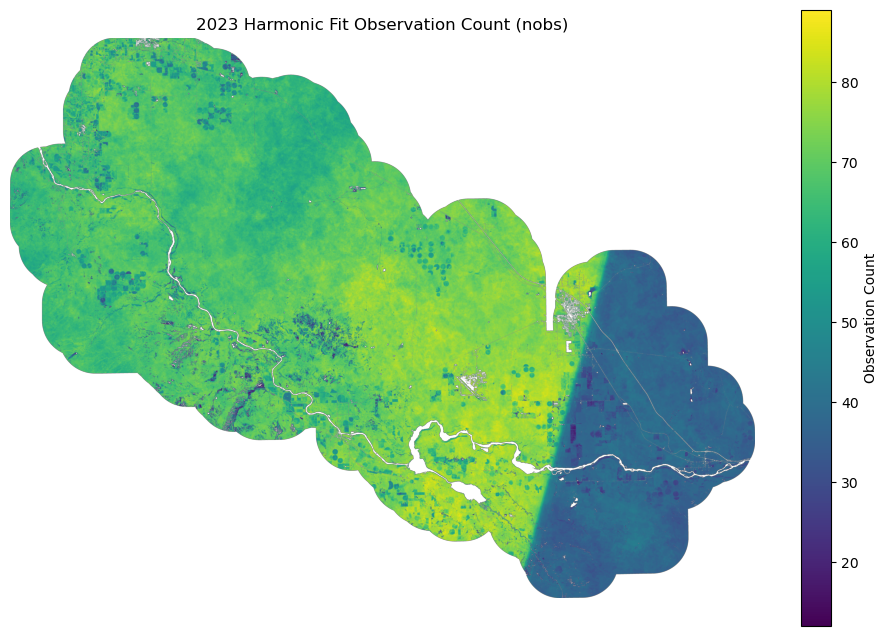

Saved: C:\NCA_DATA\Figures\2023\2023_Harmonic_Fit_Observation_Count_nobs.png


In [24]:
#nObs
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from pathlib import Path

out_vrt = r"C:\NCA_DATA\S2_Harmonics_vrt\S2SR_Harmonics_2023_4th.vrt"
fig_dir = Path(r"C:\NCA_DATA\Figures\2023")

with rasterio.open(out_vrt) as src:
    nobs = src.read(136).astype("float32")

# mask invalid counts
nobs = np.ma.masked_where((nobs <= 0) | (nobs > 200), nobs)

title = "2023 Harmonic Fit Observation Count (nobs)"

plt.figure(figsize=(12,8))
im = plt.imshow(nobs, cmap="viridis")
plt.colorbar(im, label="Observation Count")
plt.title(title)
plt.axis("off")

outfile = fig_dir / "2023_Harmonic_Fit_Observation_Count_nobs.png"

plt.savefig(outfile, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print(f"Saved: {outfile}")
#runtime ~ 2mins

In [21]:
##Histograms 1-99 percentile
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from pathlib import Path

out_vrt = r"C:\NCA_DATA\S2_Harmonics_vrt\S2SR_Harmonics_2021_4th.vrt"
fig_dir = Path(r"C:\NCA_DATA\Figures\2021\Intercept")
fig_dir.mkdir(exist_ok=True)

variables = [
    "B2", "B3", "B4", "B5", "B6", "B7", "B8", "B8A",
    "B11", "B12", "NDVI", "NDMI", "NDRE", "BSI", "NBR2"
]

index_names = {"NDVI", "NDMI", "NDRE", "BSI", "NBR2"}

with rasterio.open(out_vrt) as src:

    for i, var in enumerate(variables, start=1):

        data = src.read(i).astype("float32")
        data = np.ma.masked_where(data == -32768, data)

        vals = data.compressed()

        if len(vals) == 0:
            print(f"Skipped {var}")
            continue

        # percentile trimming
        lo, hi = np.percentile(vals, [1, 99])
        vals_trim = vals[(vals >= lo) & (vals <= hi)]

        if var in index_names:
            title = f"2021 {var} Annual Mean Index Histogram Trimmed ($\\beta_0$)"
            xlabel = f"{var} annual mean index ($\\beta_0$)"
        else:
            title = f"2021 {var} Annual Mean Reflectance Histogram Trimmed ($\\beta_0$)"
            xlabel = f"{var} annual mean reflectance ($\\beta_0$)"

        plt.figure(figsize=(12,8))
        plt.hist(vals_trim, bins=100) 
        plt.title(title)
        plt.xlabel(xlabel)
        plt.ylabel("Pixel count")

        fname = (
            title
            .replace("$\\beta_0$", "beta0")
            .replace(" ", "_")
        )

        outfile = fig_dir / f"{fname}.png"

        plt.savefig(outfile, dpi=300, bbox_inches="tight")
        plt.close()

        print(f"Saved: {outfile}")

#runtime ~ 24mins

Saved: C:\NCA_DATA\Figures\2021\Intercept\2021_B2_Annual_Mean_Reflectance_Histogram_Trimmed_(beta0).png
Saved: C:\NCA_DATA\Figures\2021\Intercept\2021_B3_Annual_Mean_Reflectance_Histogram_Trimmed_(beta0).png
Saved: C:\NCA_DATA\Figures\2021\Intercept\2021_B4_Annual_Mean_Reflectance_Histogram_Trimmed_(beta0).png
Saved: C:\NCA_DATA\Figures\2021\Intercept\2021_B5_Annual_Mean_Reflectance_Histogram_Trimmed_(beta0).png
Saved: C:\NCA_DATA\Figures\2021\Intercept\2021_B6_Annual_Mean_Reflectance_Histogram_Trimmed_(beta0).png
Saved: C:\NCA_DATA\Figures\2021\Intercept\2021_B7_Annual_Mean_Reflectance_Histogram_Trimmed_(beta0).png
Saved: C:\NCA_DATA\Figures\2021\Intercept\2021_B8_Annual_Mean_Reflectance_Histogram_Trimmed_(beta0).png
Saved: C:\NCA_DATA\Figures\2021\Intercept\2021_B8A_Annual_Mean_Reflectance_Histogram_Trimmed_(beta0).png
Saved: C:\NCA_DATA\Figures\2021\Intercept\2021_B11_Annual_Mean_Reflectance_Histogram_Trimmed_(beta0).png
Saved: C:\NCA_DATA\Figures\2021\Intercept\2021_B12_Annual_Mean

In [22]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from pathlib import Path

out_raster = Path(r"C:\NCA_DATA\S2_Harmonics_vrt\S2SR_Harmonics_2020_4th_amp_phase_masked.tif")
fig_dir = Path(r"C:\NCA_DATA\Figures\2020\Amplitude")
fig_dir.mkdir(exist_ok=True)

variables = [
    "B2", "B3", "B4", "B5", "B6", "B7", "B8", "B8A",
    "B11", "B12", "NDVI", "NDMI", "NDRE", "BSI", "NBR2"
]

index_names = {"NDVI", "NDMI", "NDRE", "BSI", "NBR2"}

with rasterio.open(out_raster) as src:

    band_names = list(src.descriptions)

    for var in variables:

        band_name = f"A1_{var}"

        if band_name not in band_names:
            print(f"Skipped {var} (band not found)")
            continue

        band_idx = band_names.index(band_name) + 1
        data = src.read(band_idx, masked=True).astype("float32")
        vals = data.compressed()

# amplitude cannot be negative
        vals = vals[vals >= 0]

# remove extreme pathological tail for display
        vals = vals[vals <= 1000]

        if len(vals) == 0:
            print(f"Skipped {var}")
            continue

        lo, hi = np.percentile(vals, [1, 99])
        vals_trim = vals[(vals >= lo) & (vals <= hi)]

        # percentile trimming
        lo, hi = np.percentile(vals, [1, 99])
        vals_trim = vals[(vals >= lo) & (vals <= hi)]

        if var in index_names:
            title = f"2020 {var} Seasonal Amplitude Histogram Trimmed (A1)"
            xlabel = f"{var} seasonal amplitude (A1)"
        else:
            title = f"2020 {var} Seasonal Reflectance Amplitude Histogram Trimmed (A1)"
            xlabel = f"{var} seasonal amplitude (A1)"

        plt.figure(figsize=(12,8))
        plt.hist(vals_trim, bins=100)
        #plt.yscale("log")
        plt.title(title)
        plt.xlabel(xlabel)
        plt.ylabel("Pixel count")

        fname = title.replace(" ", "_")

        outfile = fig_dir / f"{fname}.png"

        plt.savefig(outfile, dpi=300, bbox_inches="tight")
        plt.close()

        print(f"Saved: {outfile}")
        print(f"{var}: min={vals.min():.3f}, max={vals.max():.3f}, mean={vals.mean():.3f}")

Saved: C:\NCA_DATA\Figures\2020\Amplitude\2020_B2_Seasonal_Reflectance_Amplitude_Histogram_Trimmed_(A1).png
B2: min=0.000, max=999.795, mean=0.080
Saved: C:\NCA_DATA\Figures\2020\Amplitude\2020_B3_Seasonal_Reflectance_Amplitude_Histogram_Trimmed_(A1).png
B3: min=0.000, max=998.367, mean=0.088
Saved: C:\NCA_DATA\Figures\2020\Amplitude\2020_B4_Seasonal_Reflectance_Amplitude_Histogram_Trimmed_(A1).png
B4: min=0.000, max=999.924, mean=0.099
Saved: C:\NCA_DATA\Figures\2020\Amplitude\2020_B5_Seasonal_Reflectance_Amplitude_Histogram_Trimmed_(A1).png
B5: min=0.000, max=999.945, mean=0.099
Saved: C:\NCA_DATA\Figures\2020\Amplitude\2020_B6_Seasonal_Reflectance_Amplitude_Histogram_Trimmed_(A1).png
B6: min=0.000, max=999.708, mean=0.108
Saved: C:\NCA_DATA\Figures\2020\Amplitude\2020_B7_Seasonal_Reflectance_Amplitude_Histogram_Trimmed_(A1).png
B7: min=0.000, max=999.938, mean=0.117
Saved: C:\NCA_DATA\Figures\2020\Amplitude\2020_B8_Seasonal_Reflectance_Amplitude_Histogram_Trimmed_(A1).png
B8: min=0.

Comprehensive tif diagnostic

runs in about an hour, produces per band summaries about extremes
1  beta0_B2            
     min=-602423.6875  max=516511.5625  mean=-15377.0811
     count finite=81987795
     first unique values: [-602423.7   -352292.75  -184235.1   -172472.06  -150071.    -135398.62
 -117635.54  -111752.695 -108746.164 -103596.65 ]
     last unique values:  [185158.52 188959.42 191068.31 198053.2  198337.7  200928.52 212551.92
 293963.25 428982.4  516511.56]

 this is what prompted the amp_phase_masked runs

In [26]:
#NoData diagnostic for the new amp_phase tif because histograms are producing absurdly high bimodal values

import numpy as np
import rasterio
from pathlib import Path

out_raster = Path(r"C:\NCA_DATA\S2_Harmonics_vrt\S2SR_Harmonics_2025_4th_amp_phase.tif")

with rasterio.open(out_raster) as src:
    print("File:", out_raster.name)
    print("dtype(s):", src.dtypes)
    print("nodata metadata:", src.nodata)
    print("band count:", src.count)
    print()

    for i, desc in enumerate(src.descriptions, start=1):
        data = src.read(i)

        finite = np.isfinite(data)
        vals = data[finite]

        if vals.size == 0:
            print(f"{i:3d}  {desc:20s}  all non-finite")
            continue

        uniq_min = np.unique(vals)[:10]
        uniq_max = np.unique(vals)[-10:]

        print(f"{i:3d}  {desc:20s}")
        print(f"     min={vals.min()}  max={vals.max()}  mean={vals.mean():.4f}")
        print(f"     count finite={vals.size}")
        print(f"     first unique values: {uniq_min}")
        print(f"     last unique values:  {uniq_max}")
        print()

File: S2SR_Harmonics_2025_4th_amp_phase.tif
dtype(s): ('float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32',

In [27]:
in_raster = Path(r"C:\NCA_DATA\S2_Harmonics_vrt\S2SR_Harmonics_2025_4th.vrt")

with rasterio.open(in_raster) as src:
    m_b2 = np.ma.getmaskarray(src.read(1, masked=True))        # beta0_B2
    m_b8 = np.ma.getmaskarray(src.read(7, masked=True))        # beta0_B8
    m_rmse = np.ma.getmaskarray(src.read(136, masked=True))    # RMSE_B2

    print("B2 vs B8:", np.array_equal(m_b2, m_b8))
    print("B2 vs RMSE:", np.array_equal(m_b2, m_rmse))

B2 vs B8: True
B2 vs RMSE: False


WRITE THE RASTER!

In [25]:
import numpy as np
import rasterio
from pathlib import Path
import time

# -----------------------------------------------------------------------------
# PATHS
# -----------------------------------------------------------------------------
in_raster = Path(r"C:\NCA_DATA\S2_Harmonics_vrt\S2SR_Harmonics_2021_4th.vrt")
out_raster = Path(r"C:\NCA_DATA\S2_Harmonics_vrt\S2SR_Harmonics_2021_4th_amp_phase_masked.tif")

# -----------------------------------------------------------------------------
# VARIABLES
# -----------------------------------------------------------------------------
variables = [
    "B2", "B3", "B4", "B5", "B6", "B7", "B8",
    "B8A", "B11", "B12",
    "NDVI", "NDMI", "NDRE", "BSI", "NBR2"
]

offsets = {
    "constant": 0,
    "sin1": 15,
    "cos1": 30,
    "sin2": 45,
    "cos2": 60,
    "sin3": 75,
    "cos3": 90,
    "sin4": 105,
    "cos4": 120,
    "nobs": 135,
    "RMSE": 136,
}

var_to_idx = {v: i for i, v in enumerate(variables)}

# -----------------------------------------------------------------------------
# HELPERS
# -----------------------------------------------------------------------------
def read_band_0based(src, idx0):
    return src.read(idx0 + 1).astype("float32")

def amp_phase(cos_arr, sin_arr):
    A = np.sqrt(cos_arr * cos_arr + sin_arr * sin_arr).astype("float32")
    phi = np.arctan2(sin_arr, cos_arr).astype("float32")
    return A, phi

def apply_mask(arr, mask, nodata):
    out = np.asarray(arr, dtype="float32").copy()
    out[mask] = nodata
    return out

def file_size_gb(path):
    return path.stat().st_size / 1e9 if path.exists() else 0.0

# -----------------------------------------------------------------------------
# BAND NAMES
# -----------------------------------------------------------------------------
out_band_names = []
for var in variables:
    out_band_names.extend([
        f"beta0_{var}",
        f"A1_{var}", f"phi1_{var}",
        f"A2_{var}", f"phi2_{var}",
        f"A3_{var}", f"phi3_{var}",
        f"A4_{var}", f"phi4_{var}",
        f"RMSE_{var}",
    ])
out_band_names.append("nobs")

# -----------------------------------------------------------------------------
# PROCESS
# -----------------------------------------------------------------------------
t0 = time.time()

with rasterio.open(in_raster) as src:

    nodata = src.nodata if src.nodata is not None else -32768.0

    # 🔑 GLOBAL MASK FROM beta0_B2
    beta0_B2 = src.read(1, masked=True)
    global_mask = np.ma.getmaskarray(beta0_B2)

    # output profile
    profile = src.profile.copy()
    profile.update(
        driver="GTiff",
        dtype="float32",
        count=len(out_band_names),
        nodata=nodata,
        tiled=True,
        blockxsize=256,
        blockysize=256,
        compress=None,   # use LZW if ZSTD not available
        predictor=3,
        BIGTIFF="IF_SAFER"
    )

    with rasterio.open(out_raster, "w", **profile) as dst:

        out_band_num = 1

        for i, var in enumerate(variables, start=1):

            j = var_to_idx[var]

            # read harmonic coefficients
            beta0 = read_band_0based(src, offsets["constant"] + j)
            sin1  = read_band_0based(src, offsets["sin1"] + j)
            cos1  = read_band_0based(src, offsets["cos1"] + j)
            sin2  = read_band_0based(src, offsets["sin2"] + j)
            cos2  = read_band_0based(src, offsets["cos2"] + j)
            sin3  = read_band_0based(src, offsets["sin3"] + j)
            cos3  = read_band_0based(src, offsets["cos3"] + j)
            sin4  = read_band_0based(src, offsets["sin4"] + j)
            cos4  = read_band_0based(src, offsets["cos4"] + j)
            rmse  = read_band_0based(src, offsets["RMSE"] + j)

            # compute amplitude + phase
            A1, phi1 = amp_phase(cos1, sin1)
            A2, phi2 = amp_phase(cos2, sin2)
            A3, phi3 = amp_phase(cos3, sin3)
            A4, phi4 = amp_phase(cos4, sin4)

            grouped = [
                beta0,
                A1, phi1,
                A2, phi2,
                A3, phi3,
                A4, phi4,
                rmse
            ]

            # write all bands with global mask
            for arr, desc in zip(
                grouped,
                out_band_names[out_band_num - 1 : out_band_num - 1 + 10]
            ):
                dst.write(apply_mask(arr, global_mask, nodata), out_band_num)
                dst.set_band_description(out_band_num, desc)
                out_band_num += 1

            print(f"[{i:02d}/{len(variables)}] {var:<5} | size: {file_size_gb(out_raster):.2f} GB")

        # write nobs with same mask
        nobs = read_band_0based(src, offsets["nobs"])
        dst.write(apply_mask(nobs, global_mask, nodata), out_band_num)
        dst.set_band_description(out_band_num, "nobs")

# -----------------------------------------------------------------------------
# DONE
# -----------------------------------------------------------------------------
print(f"Done: {out_raster}")
print(f"Final size: {file_size_gb(out_raster):.2f} GB")
print(f"Elapsed min: {(time.time() - t0)/60:.1f}")
#276 mins; 50gb

[01/15] B2    | size: 50.27 GB
[02/15] B3    | size: 50.31 GB
[03/15] B4    | size: 50.31 GB
[04/15] B5    | size: 50.31 GB
[05/15] B6    | size: 50.31 GB
[06/15] B7    | size: 50.31 GB
[07/15] B8    | size: 50.31 GB
[08/15] B8A   | size: 50.31 GB
[09/15] B11   | size: 50.31 GB
[10/15] B12   | size: 50.31 GB
[11/15] NDVI  | size: 50.31 GB
[12/15] NDMI  | size: 50.31 GB
[13/15] NDRE  | size: 50.31 GB
[14/15] BSI   | size: 50.31 GB
[15/15] NBR2  | size: 50.31 GB
Done: C:\NCA_DATA\S2_Harmonics_vrt\S2SR_Harmonics_2021_4th_amp_phase_masked.tif
Final size: 50.31 GB
Elapsed min: 270.4


In [28]:
import numpy as np
import rasterio
from pathlib import Path
import time

# -----------------------------------------------------------------------------
# PATHS
# -----------------------------------------------------------------------------
in_raster = Path(r"C:\NCA_DATA\S2_Harmonics_vrt\S2SR_Harmonics_2024_4th.vrt")
out_raster = Path(r"C:\NCA_DATA\S2_Harmonics_vrt\S2SR_Harmonics_2024_4th_amp_phase_masked.tif")

# -----------------------------------------------------------------------------
# VARIABLES
# -----------------------------------------------------------------------------
variables = [
    "B2", "B3", "B4", "B5", "B6", "B7", "B8",
    "B8A", "B11", "B12",
    "NDVI", "NDMI", "NDRE", "BSI", "NBR2"
]

offsets = {
    "constant": 0,
    "sin1": 15,
    "cos1": 30,
    "sin2": 45,
    "cos2": 60,
    "sin3": 75,
    "cos3": 90,
    "sin4": 105,
    "cos4": 120,
    "nobs": 135,
    "RMSE": 136,
}

var_to_idx = {v: i for i, v in enumerate(variables)}

# -----------------------------------------------------------------------------
# HELPERS
# -----------------------------------------------------------------------------
def read_band_0based(src, idx0):
    return src.read(idx0 + 1).astype("float32")

def amp_phase(cos_arr, sin_arr):
    A = np.sqrt(cos_arr * cos_arr + sin_arr * sin_arr).astype("float32")
    phi = np.arctan2(sin_arr, cos_arr).astype("float32")
    return A, phi

def apply_mask(arr, mask, nodata):
    out = np.asarray(arr, dtype="float32").copy()
    out[mask] = nodata
    return out

def file_size_gb(path):
    return path.stat().st_size / 1e9 if path.exists() else 0.0

# -----------------------------------------------------------------------------
# BAND NAMES
# -----------------------------------------------------------------------------
out_band_names = []
for var in variables:
    out_band_names.extend([
        f"beta0_{var}",
        f"A1_{var}", f"phi1_{var}",
        f"A2_{var}", f"phi2_{var}",
        f"A3_{var}", f"phi3_{var}",
        f"A4_{var}", f"phi4_{var}",
        f"RMSE_{var}",
    ])
out_band_names.append("nobs")

# -----------------------------------------------------------------------------
# PROCESS
# -----------------------------------------------------------------------------
t0 = time.time()

with rasterio.open(in_raster) as src:

    nodata = src.nodata if src.nodata is not None else -32768.0

    # 🔑 GLOBAL MASK FROM beta0_B2
    beta0_B2 = src.read(1, masked=True)
    global_mask = np.ma.getmaskarray(beta0_B2)

    # output profile
    profile = src.profile.copy()
    profile.update(
        driver="GTiff",
        dtype="float32",
        count=len(out_band_names),
        nodata=nodata,
        tiled=True,
        blockxsize=256,
        blockysize=256,
        compress=None,   # use LZW if ZSTD not available
        predictor=3,
        BIGTIFF="IF_SAFER"
    )

    with rasterio.open(out_raster, "w", **profile) as dst:

        out_band_num = 1

        for i, var in enumerate(variables, start=1):

            j = var_to_idx[var]

            # read harmonic coefficients
            beta0 = read_band_0based(src, offsets["constant"] + j)
            sin1  = read_band_0based(src, offsets["sin1"] + j)
            cos1  = read_band_0based(src, offsets["cos1"] + j)
            sin2  = read_band_0based(src, offsets["sin2"] + j)
            cos2  = read_band_0based(src, offsets["cos2"] + j)
            sin3  = read_band_0based(src, offsets["sin3"] + j)
            cos3  = read_band_0based(src, offsets["cos3"] + j)
            sin4  = read_band_0based(src, offsets["sin4"] + j)
            cos4  = read_band_0based(src, offsets["cos4"] + j)
            rmse  = read_band_0based(src, offsets["RMSE"] + j)

            # compute amplitude + phase
            A1, phi1 = amp_phase(cos1, sin1)
            A2, phi2 = amp_phase(cos2, sin2)
            A3, phi3 = amp_phase(cos3, sin3)
            A4, phi4 = amp_phase(cos4, sin4)

            grouped = [
                beta0,
                A1, phi1,
                A2, phi2,
                A3, phi3,
                A4, phi4,
                rmse
            ]

            # write all bands with global mask
            for arr, desc in zip(
                grouped,
                out_band_names[out_band_num - 1 : out_band_num - 1 + 10]
            ):
                dst.write(apply_mask(arr, global_mask, nodata), out_band_num)
                dst.set_band_description(out_band_num, desc)
                out_band_num += 1

            print(f"[{i:02d}/{len(variables)}] {var:<5} | size: {file_size_gb(out_raster):.2f} GB")

        # write nobs with same mask
        nobs = read_band_0based(src, offsets["nobs"])
        dst.write(apply_mask(nobs, global_mask, nodata), out_band_num)
        dst.set_band_description(out_band_num, "nobs")

# -----------------------------------------------------------------------------
# DONE
# -----------------------------------------------------------------------------
print(f"Done: {out_raster}")
print(f"Final size: {file_size_gb(out_raster):.2f} GB")
print(f"Elapsed min: {(time.time() - t0)/60:.1f}")
#276 mins; 50gb

[01/15] B2    | size: 50.27 GB
[02/15] B3    | size: 50.31 GB
[03/15] B4    | size: 50.31 GB
[04/15] B5    | size: 50.31 GB
[05/15] B6    | size: 50.31 GB
[06/15] B7    | size: 50.31 GB
[07/15] B8    | size: 50.31 GB
[08/15] B8A   | size: 50.31 GB
[09/15] B11   | size: 50.31 GB
[10/15] B12   | size: 50.31 GB
[11/15] NDVI  | size: 50.31 GB
[12/15] NDMI  | size: 50.31 GB
[13/15] NDRE  | size: 50.31 GB
[14/15] BSI   | size: 50.31 GB
[15/15] NBR2  | size: 50.31 GB
Done: C:\NCA_DATA\S2_Harmonics_vrt\S2SR_Harmonics_2024_4th_amp_phase_masked.tif
Final size: 50.31 GB
Elapsed min: 275.0


In [11]:
# build the constant, amplitude, phase mosaic using the VRT file
# B9 removed; stack layout matches 151-band export

import numpy as np
import rasterio
from pathlib import Path
import time

# -----------------------------------------------------------------------------
# INPUTS
# -----------------------------------------------------------------------------
in_raster = Path(r"C:\NCA_DATA\S2_Harmonics_vrt\S2SR_Harmonics_2025_4th.vrt")
out_raster = Path(r"C:\NCA_DATA\S2_Harmonics_vrt\S2SR_Harmonics_2025_4th_amp_phase.tif")

# Set to True if you want to keep all variables in the stack
# Set to False and edit selected_vars if you only want a subset
keep_all_variables = True

selected_vars = [
    "B2", "B3", "B4", "B5", "B6", "B7", "B8",
    "B8A", "B11", "B12",
    "NDVI", "NDMI", "NDRE", "BSI", "NBR2"
]

# -----------------------------------------------------------------------------
# BAND INDEX MAP FROM THE 151-BAND STACK (0-based indices)
# -----------------------------------------------------------------------------
variables = [
    "B2", "B3", "B4", "B5", "B6", "B7", "B8",
    "B8A", "B11", "B12",
    "NDVI", "NDMI", "NDRE", "BSI", "NBR2"
]

if not keep_all_variables:
    variables = [v for v in variables if v in selected_vars]

# Base offsets in the original stack (15 vars per harmonic block)
# 0–14:   constant_*
# 15–29:  sin1_*
# 30–44:  cos1_*
# 45–59:  sin2_*
# 60–74:  cos2_*
# 75–89:  sin3_*
# 90–104: cos3_*
# 105–119: sin4_*
# 120–134: cos4_*
# 135:    nobs
# 136–150: RMSE_*

offsets = {
    "constant": 0,
    "sin1": 15,
    "cos1": 30,
    "sin2": 45,
    "cos2": 60,
    "sin3": 75,
    "cos3": 90,
    "sin4": 105,
    "cos4": 120,
    "nobs": 135,
    "RMSE": 136,
}

var_to_idx = {v: i for i, v in enumerate([
    "B2", "B3", "B4", "B5", "B6", "B7", "B8",
    "B8A", "B11", "B12",
    "NDVI", "NDMI", "NDRE", "BSI", "NBR2"
])}

# -----------------------------------------------------------------------------
# HELPERS
# -----------------------------------------------------------------------------
def read_band_0based(src, idx0):
    """
    Read a band using 0-based indexing from the schema above.
    Rasterio itself is 1-based, so add 1 here.
    """
    return src.read(idx0 + 1).astype("float32")

def amp_phase(cos_arr, sin_arr):
    """
    Compute amplitude and phase from cosine and sine coefficients.

    A = sqrt(cos^2 + sin^2)
    phi = atan2(sin, cos)

    This matches:
        y = beta0 + A*cos(wt - phi)
    """
    A = np.sqrt(cos_arr * cos_arr + sin_arr * sin_arr).astype("float32")
    phi = np.arctan2(sin_arr, cos_arr).astype("float32")
    return A, phi

def file_size_gb(path):
    """
    Return file size in decimal GB.
    """
    if not path.exists():
        return 0.0
    return path.stat().st_size / 1e9

# -----------------------------------------------------------------------------
# BUILD OUTPUT SCHEMA
# -----------------------------------------------------------------------------
out_band_names = []
for var in variables:
    out_band_names.extend([
        f"beta0_{var}",
        f"A1_{var}", f"phi1_{var}",
        f"A2_{var}", f"phi2_{var}",
        f"A3_{var}", f"phi3_{var}",
        f"A4_{var}", f"phi4_{var}",
        f"RMSE_{var}",
    ])
out_band_names.append("nobs")

n_out = len(out_band_names)
assert n_out == len(variables) * 10 + 1

print("Output schema:")
for i, name in enumerate(out_band_names, start=1):
    print(f"{i:03d}: {name}")

# -----------------------------------------------------------------------------
# PROCESS + WRITE
# -----------------------------------------------------------------------------
t0 = time.time()

with rasterio.open(in_raster) as src:
    profile = src.profile.copy()

    # Optional safety check
    expected_input_bands = 151
    if src.count != expected_input_bands:
        raise RuntimeError(
            f"Expected input raster to have {expected_input_bands} bands, found {src.count}."
        )

    profile.pop("compress", None)
    profile.pop("predictor", None)

    profile.update(
        driver="GTiff",
        dtype="float32",
        count=n_out,
        compress="NONE",
        tiled=True,
        blockxsize=256,
        blockysize=256,
        BIGTIFF="IF_SAFER"
    )

    # carry nodata if present
    nodata = src.nodata
    if nodata is not None:
        profile.update(nodata=nodata)

    with rasterio.open(out_raster, "w", **profile) as dst:
        out_band_num = 1

        for i, var in enumerate(variables, start=1):
            t_var0 = time.time()
            j = var_to_idx[var]

            beta0 = read_band_0based(src, offsets["constant"] + j)
            sin1  = read_band_0based(src, offsets["sin1"] + j)
            cos1  = read_band_0based(src, offsets["cos1"] + j)
            sin2  = read_band_0based(src, offsets["sin2"] + j)
            cos2  = read_band_0based(src, offsets["cos2"] + j)
            sin3  = read_band_0based(src, offsets["sin3"] + j)
            cos3  = read_band_0based(src, offsets["cos3"] + j)
            sin4  = read_band_0based(src, offsets["sin4"] + j)
            cos4  = read_band_0based(src, offsets["cos4"] + j)
            rmse  = read_band_0based(src, offsets["RMSE"] + j)

            A1, phi1 = amp_phase(cos1, sin1)
            A2, phi2 = amp_phase(cos2, sin2)
            A3, phi3 = amp_phase(cos3, sin3)
            A4, phi4 = amp_phase(cos4, sin4)

            grouped = [
                beta0,
                A1, phi1,
                A2, phi2,
                A3, phi3,
                A4, phi4,
                rmse,
            ]

            these_names = out_band_names[out_band_num - 1: out_band_num - 1 + len(grouped)]

            for arr, desc in zip(grouped, these_names):
                dst.write(arr, out_band_num)
                dst.set_band_description(out_band_num, desc)
                out_band_num += 1

            elapsed_total = time.time() - t0
            elapsed_var = time.time() - t_var0
            size_gb = file_size_gb(out_raster)
            pct = (i / len(variables)) * 100.0

            print(
                f"[{i:02d}/{len(variables)} | {pct:5.1f}%] "
                f"{var:<5} done in {elapsed_var:6.1f}s | "
                f"bands written: {out_band_num - 1:3d}/{n_out} | "
                f"file size: {size_gb:7.2f} GB | "
                f"elapsed: {elapsed_total/60:6.1f} min"
            )

            if size_gb > 100:
                raise RuntimeError(
                    f"Output file exceeded 100 GB ({size_gb:.2f} GB). "
                    f"Aborting write to prevent runaway disk usage."
                )

            del beta0, sin1, cos1, sin2, cos2, sin3, cos3, sin4, cos4, rmse
            del A1, phi1, A2, phi2, A3, phi3, A4, phi4, grouped, these_names

        # write shared nobs once at the end
        nobs = read_band_0based(src, offsets["nobs"])
        dst.write(nobs, out_band_num)
        dst.set_band_description(out_band_num, "nobs")

        final_size_gb = file_size_gb(out_raster)
        print(
            f"[FINAL] nobs written | bands written: {out_band_num}/{n_out} | "
            f"file size: {final_size_gb:.2f} GB | "
            f"elapsed: {(time.time() - t0)/60:.1f} min"
        )

        assert out_band_num == n_out, f"Expected to write band {n_out}, got {out_band_num}"

print(f"\nWrote: {out_raster}")
print(f"Total output bands: {n_out}")
print(f"Final size: {file_size_gb(out_raster):.2f} GB")

Output schema:
001: beta0_B2
002: A1_B2
003: phi1_B2
004: A2_B2
005: phi2_B2
006: A3_B2
007: phi3_B2
008: A4_B2
009: phi4_B2
010: RMSE_B2
011: beta0_B3
012: A1_B3
013: phi1_B3
014: A2_B3
015: phi2_B3
016: A3_B3
017: phi3_B3
018: A4_B3
019: phi4_B3
020: RMSE_B3
021: beta0_B4
022: A1_B4
023: phi1_B4
024: A2_B4
025: phi2_B4
026: A3_B4
027: phi3_B4
028: A4_B4
029: phi4_B4
030: RMSE_B4
031: beta0_B5
032: A1_B5
033: phi1_B5
034: A2_B5
035: phi2_B5
036: A3_B5
037: phi3_B5
038: A4_B5
039: phi4_B5
040: RMSE_B5
041: beta0_B6
042: A1_B6
043: phi1_B6
044: A2_B6
045: phi2_B6
046: A3_B6
047: phi3_B6
048: A4_B6
049: phi4_B6
050: RMSE_B6
051: beta0_B7
052: A1_B7
053: phi1_B7
054: A2_B7
055: phi2_B7
056: A3_B7
057: phi3_B7
058: A4_B7
059: phi4_B7
060: RMSE_B7
061: beta0_B8
062: A1_B8
063: phi1_B8
064: A2_B8
065: phi2_B8
066: A3_B8
067: phi3_B8
068: A4_B8
069: phi4_B8
070: RMSE_B8
071: beta0_B8A
072: A1_B8A
073: phi1_B8A
074: A2_B8A
075: phi2_B8A
076: A3_B8A
077: phi3_B8A
078: A4_B8A
079: phi4_B8A
080: 

In [ ]:
#verify the write metadata
import rasterio

path = r"C:\NCA_DATA\S2_Harmonics_vrt\S2SR_Harmonics_2025_4th_amp_phase.tif"

with rasterio.open(path) as src:
    print("Driver:", src.driver)
    print("Width:", src.width)
    print("Height:", src.height)
    print("Count:", src.count)
    print("Dtype:", src.dtypes[0])
    print("Compression:", src.compression)
    print("Block shapes:", src.block_shapes[:5])
    print("Tiled:", src.is_tiled)
    print("Nodata:", src.nodata)

Driver: GTiff
Width: 10435
Height: 7857
Count: 151
Dtype: float32
Compression: None
Block shapes: [(256, 256), (256, 256), (256, 256), (256, 256), (256, 256)]
Tiled: True
Nodata: -32768.0


In [13]:
#raster wrote but with no NoData value...
import rasterio

with rasterio.open(path) as src:
    for i, desc in enumerate(src.descriptions, start=1):
        print(f"{i:03d}  {desc}")

001  beta0_B2
002  A1_B2
003  phi1_B2
004  A2_B2
005  phi2_B2
006  A3_B2
007  phi3_B2
008  A4_B2
009  phi4_B2
010  RMSE_B2
011  beta0_B3
012  A1_B3
013  phi1_B3
014  A2_B3
015  phi2_B3
016  A3_B3
017  phi3_B3
018  A4_B3
019  phi4_B3
020  RMSE_B3
021  beta0_B4
022  A1_B4
023  phi1_B4
024  A2_B4
025  phi2_B4
026  A3_B4
027  phi3_B4
028  A4_B4
029  phi4_B4
030  RMSE_B4
031  beta0_B5
032  A1_B5
033  phi1_B5
034  A2_B5
035  phi2_B5
036  A3_B5
037  phi3_B5
038  A4_B5
039  phi4_B5
040  RMSE_B5
041  beta0_B6
042  A1_B6
043  phi1_B6
044  A2_B6
045  phi2_B6
046  A3_B6
047  phi3_B6
048  A4_B6
049  phi4_B6
050  RMSE_B6
051  beta0_B7
052  A1_B7
053  phi1_B7
054  A2_B7
055  phi2_B7
056  A3_B7
057  phi3_B7
058  A4_B7
059  phi4_B7
060  RMSE_B7
061  beta0_B8
062  A1_B8
063  phi1_B8
064  A2_B8
065  phi2_B8
066  A3_B8
067  phi3_B8
068  A4_B8
069  phi4_B8
070  RMSE_B8
071  beta0_B8A
072  A1_B8A
073  phi1_B8A
074  A2_B8A
075  phi2_B8A
076  A3_B8A
077  phi3_B8A
078  A4_B8A
079  phi4_B8A
080  RMSE_B8A
081  b

Loop through all amplitude next

In [1]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# SETTINGS
# ============================================================
#years = range(2018, 2026)
years = range(2024,2026)

amp_dir = Path(r"C:\NCA_DATA\S2_Harmonics_vrt")
fig_root = Path(r"C:\NCA_DATA\Figures")

index_names = {"NDVI", "NDMI", "NDRE", "BSI", "NBR2"}

# ============================================================
# LOOP
# ============================================================
for year in years:

    raster_path = amp_dir / f"S2SR_Harmonics_{year}_4th_amp_phase_masked.tif"
    fig_dir = fig_root / str(year) / "Amplitude"
    fig_dir.mkdir(parents=True, exist_ok=True)

    if not raster_path.exists():
        print(f"{year}: raster not found, skipping")
        continue

    with rasterio.open(raster_path) as src:

        band_names = list(src.descriptions)

        for band_idx, band_name in enumerate(band_names, start=1):

            # only A1 bands
            if band_name is None or not band_name.startswith("A1_"):
                continue

            var = band_name.replace("A1_", "")

            # output names
            if var in index_names:
                base_title = f"{year} {var} Seasonal Amplitude (A1)"
            else:
                base_title = f"{year} {var} Seasonal Reflectance Amplitude (A1)"

            hist_title = base_title + " Histogram Trimmed"
            map_title  = base_title + " Map"

            hist_file = fig_dir / f"{hist_title.replace(' ', '_')}.png"
            map_file  = fig_dir / f"{map_title.replace(' ', '_')}.png"

            # skip if already done
            if hist_file.exists() and map_file.exists():
                print(f"{year} {band_name}: skipped (exists)")
                continue

            # ------------------------------------------------------------
            # READ DATA
            # ------------------------------------------------------------
            data = src.read(band_idx, masked=True).astype("float32")
            vals = data.compressed()

            # same logic as your script
            vals = vals[vals >= 0]
            vals = vals[vals <= 1000]

            if len(vals) == 0:
                print(f"{year} {band_name}: no valid data")
                continue

            lo, hi = np.percentile(vals, [1, 99])
            vals_trim = vals[(vals >= lo) & (vals <= hi)]

            # ------------------------------------------------------------
            # HISTOGRAM
            # ------------------------------------------------------------
            if not hist_file.exists():
                plt.figure(figsize=(12,8))
                plt.hist(vals_trim, bins=100)
                plt.title(hist_title)
                plt.xlabel(f"{var} seasonal amplitude (A1)")
                plt.ylabel("Pixel count")
                plt.savefig(hist_file, dpi=300, bbox_inches="tight")
                plt.close()
                print(f"Saved histogram: {hist_file}")

            # ------------------------------------------------------------
            # MAP
            # ------------------------------------------------------------
            if not map_file.exists():
                plt.figure(figsize=(12,8))
                plt.imshow(data, cmap="viridis", vmin=lo, vmax=hi)
                plt.colorbar()
                plt.title(map_title)
                plt.axis("off")
                plt.savefig(map_file, dpi=300, bbox_inches="tight")
                plt.close()
                print(f"Saved map: {map_file}")

            print(f"{year} {var}: min={vals.min():.3f}, max={vals.max():.3f}, mean={vals.mean():.3f}")

print("Done.")

2024 A1_B2: skipped (exists)
2024 A1_B3: skipped (exists)
2024 A1_B4: skipped (exists)
2024 A1_B5: skipped (exists)
2024 A1_B6: skipped (exists)
2024 A1_B7: skipped (exists)
2024 A1_B8: skipped (exists)
2024 A1_B8A: skipped (exists)
2024 A1_B11: skipped (exists)
2024 A1_B12: skipped (exists)
2024 A1_NDVI: skipped (exists)
Saved map: C:\NCA_DATA\Figures\2024\Amplitude\2024_NDMI_Seasonal_Amplitude_(A1)_Map.png
2024 NDMI: min=0.000, max=999.596, mean=0.235
Saved histogram: C:\NCA_DATA\Figures\2024\Amplitude\2024_NDRE_Seasonal_Amplitude_(A1)_Histogram_Trimmed.png
Saved map: C:\NCA_DATA\Figures\2024\Amplitude\2024_NDRE_Seasonal_Amplitude_(A1)_Map.png
2024 NDRE: min=0.000, max=999.468, mean=0.120
Saved histogram: C:\NCA_DATA\Figures\2024\Amplitude\2024_BSI_Seasonal_Amplitude_(A1)_Histogram_Trimmed.png
Saved map: C:\NCA_DATA\Figures\2024\Amplitude\2024_BSI_Seasonal_Amplitude_(A1)_Map.png
2024 BSI: min=0.000, max=999.666, mean=0.231
Saved histogram: C:\NCA_DATA\Figures\2024\Amplitude\2024_NBR2

In [9]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# SETTINGS
# ============================================================
#years = range(2024, 2026)
years = range(2018, 2026)

amp_dir = Path(r"C:\NCA_DATA\S2_Harmonics_vrt")
fig_root = Path(r"C:\NCA_DATA\Figures")

index_names = {"NDVI", "NDMI", "NDRE", "BSI", "NBR2"}

# global display trimming per band across all years
p_lo = 1
p_hi = 99

# sampling for percentile estimation (keeps memory reasonable)
sample_per_year = 200000
rng = np.random.default_rng(42)

# overwrite existing files
overwrite = True

# ============================================================
# PASS 1: COMPUTE GLOBAL RANGES PER BAND ACROSS YEARS
# ============================================================
band_samples = {}
# band_samples["A1_B2"] = [sample arrays from multiple years]

for year in years:
    raster_path = amp_dir / f"S2SR_Harmonics_{year}_4th_amp_phase_masked.tif"

    if not raster_path.exists():
        print(f"{year}: raster not found, skipping percentile pass")
        continue

    with rasterio.open(raster_path) as src:
        band_names = list(src.descriptions)

        for band_idx, band_name in enumerate(band_names, start=1):
            if band_name is None or not band_name.startswith("A1_"):
                continue

            data = src.read(band_idx, masked=True).astype("float32")
            vals = data.compressed()

            vals = vals[vals >= 0]
            vals = vals[vals <= 1000]

            if len(vals) == 0:
                continue

            if len(vals) > sample_per_year:
                vals = rng.choice(vals, size=sample_per_year, replace=False)

            band_samples.setdefault(band_name, []).append(vals)

# compute global vmin/vmax per band
global_ranges = {}
for band_name, chunks in band_samples.items():
    all_vals = np.concatenate(chunks)
    lo, hi = np.percentile(all_vals, [p_lo, p_hi])
    global_ranges[band_name] = (lo, hi)
    print(f"{band_name}: global {p_lo}-{p_hi} pct = {lo:.6f}, {hi:.6f}")

# ============================================================
# PASS 2: WRITE CONSISTENT PNGS
# ============================================================
for year in years:

    raster_path = amp_dir / f"S2SR_Harmonics_{year}_4th_amp_phase_masked.tif"
    fig_dir = fig_root / str(year) / "Amplitude"
    fig_dir.mkdir(parents=True, exist_ok=True)

    if not raster_path.exists():
        print(f"{year}: raster not found, skipping")
        continue

    with rasterio.open(raster_path) as src:
        band_names = list(src.descriptions)

        for band_idx, band_name in enumerate(band_names, start=1):

            if band_name is None or not band_name.startswith("A1_"):
                continue

            if band_name not in global_ranges:
                print(f"{year} {band_name}: no global range found, skipping")
                continue

            var = band_name.replace("A1_", "")
            lo, hi = global_ranges[band_name]

            if var in index_names:
                base_title = f"{year} {var} Seasonal Amplitude (A1)"
            else:
                base_title = f"{year} {var} Seasonal Reflectance Amplitude (A1)"

            hist_title = base_title + " Histogram Trimmed"
            map_title  = base_title + " Map"

            hist_file = fig_dir / f"{hist_title.replace(' ', '_')}.png"
            map_file  = fig_dir / f"{map_title.replace(' ', '_')}.png"

            if (not overwrite) and hist_file.exists() and map_file.exists():
                print(f"{year} {band_name}: skipped (exists)")
                continue

            # ------------------------------------------------------------
            # READ DATA
            # ------------------------------------------------------------
            data = src.read(band_idx, masked=True).astype("float32")
            vals = data.compressed()

            vals = vals[vals >= 0]
            vals = vals[vals <= 1000]

            if len(vals) == 0:
                print(f"{year} {band_name}: no valid data")
                continue

            vals_trim = vals[(vals >= lo) & (vals <= hi)]

            if len(vals_trim) == 0:
                print(f"{year} {band_name}: no values inside global range")
                continue

            # ------------------------------------------------------------
            # HISTOGRAM (fixed x-axis across years for each band)
            # ------------------------------------------------------------
            fig, ax = plt.subplots(figsize=(12, 8))
            ax.hist(vals_trim, bins=100, range=(lo, hi))
            ax.set_title(hist_title)
            ax.set_xlabel(f"{var} seasonal amplitude (A1)")
            ax.set_ylabel("Pixel count")
            ax.set_xlim(lo, hi)
            fig.subplots_adjust(left=0.10, right=0.95, bottom=0.12, top=0.90)
            fig.savefig(hist_file, dpi=300)
            plt.close(fig)
            print(f"Saved histogram: {hist_file}")

            # ------------------------------------------------------------
            # MAP (fixed color scale + fixed layout)
            # ------------------------------------------------------------
            fig, ax = plt.subplots(figsize=(12, 8))
            im = ax.imshow(data, cmap="viridis", vmin=lo, vmax=hi)
            cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            cbar.set_label(f"{var} amplitude (A1)")
            ax.set_title(map_title)
            ax.axis("off")
            fig.subplots_adjust(left=0.02, right=0.88, bottom=0.02, top=0.92)
            fig.savefig(map_file, dpi=300)
            plt.close(fig)
            print(f"Saved map: {map_file}")

            print(
                f"{year} {var}: min={vals.min():.6f}, "
                f"max={vals.max():.6f}, mean={vals.mean():.6f}, "
                f"map scale=({lo:.6f}, {hi:.6f})"
            )

print("Done.")

A1_B2: global 1-99 pct = 0.002178, 0.067417
A1_B3: global 1-99 pct = 0.002801, 0.078302
A1_B4: global 1-99 pct = 0.005100, 0.121869
A1_B5: global 1-99 pct = 0.004296, 0.113546
A1_B6: global 1-99 pct = 0.005070, 0.155025
A1_B7: global 1-99 pct = 0.005878, 0.203094
A1_B8: global 1-99 pct = 0.005194, 0.200498
A1_B8A: global 1-99 pct = 0.006370, 0.203208
A1_B11: global 1-99 pct = 0.007073, 0.142689
A1_B12: global 1-99 pct = 0.008141, 0.139340
A1_NDVI: global 1-99 pct = 0.007559, 0.427816
A1_NDMI: global 1-99 pct = 0.005580, 0.360376
A1_NDRE: global 1-99 pct = 0.001665, 0.094231
A1_BSI: global 1-99 pct = 0.004478, 0.360614
A1_NBR2: global 1-99 pct = 0.003786, 0.178242
Saved histogram: C:\NCA_DATA\Figures\2018\Amplitude\2018_B2_Seasonal_Reflectance_Amplitude_(A1)_Histogram_Trimmed.png
Saved map: C:\NCA_DATA\Figures\2018\Amplitude\2018_B2_Seasonal_Reflectance_Amplitude_(A1)_Map.png
2018 B2: min=0.000003, max=999.466675, mean=0.075221, map scale=(0.002178, 0.067417)
Saved histogram: C:\NCA_DAT

In [12]:
#fix the histograms!
from pathlib import Path
import numpy as np
import rasterio
import matplotlib.pyplot as plt

# ============================================================
# SETTINGS
# ============================================================
years = range(2018, 2026)

amp_dir = Path(r"C:\NCA_DATA\S2_Harmonics_vrt")
fig_root = Path(r"C:\NCA_DATA\Figures")
product_folder = "Amplitude"

bins = 80
nodata_values = {-32768, -9999}

GLOBAL_XLIMS = {
    "A1_B2":   (0.002178, 0.067417),
    "A1_B3":   (0.002801, 0.078302),
    "A1_B4":   (0.005100, 0.121869),
    "A1_B5":   (0.004296, 0.113546),
    "A1_B6":   (0.005070, 0.155025),
    "A1_B7":   (0.005878, 0.203094),
    "A1_B8":   (0.005194, 0.200498),
    "A1_B8A":  (0.006370, 0.203208),
    "A1_B11":  (0.007073, 0.142689),
    "A1_B12":  (0.008141, 0.139340),
    "A1_NDVI": (0.007559, 0.427816),
    "A1_NDMI": (0.005580, 0.360376),
    "A1_NDRE": (0.001665, 0.094231),
    "A1_BSI":  (0.004478, 0.360614),
    "A1_NBR2": (0.003786, 0.178242),
}

INDEX_NAMES = {"NDVI", "NDMI", "NDRE", "BSI", "NBR2"}

# ============================================================
# HELPERS
# ============================================================
def clean_values(arr):
    arr = arr.astype("float32", copy=False)
    mask = np.isfinite(arr)

    for nd in nodata_values:
        mask &= arr != nd

    return arr[mask]


def find_band_index(src, band_name):
    desc = list(src.descriptions)

    if band_name in desc:
        return desc.index(band_name) + 1

    raise ValueError(f"Band not found: {band_name}")


def output_hist_name(year, band_name):
    """
    Converts:
      A1_B2   -> 2025_B2_Seasonal_Reflectance_Amplitude_Histogram_Trimmed_(A1).png
      A1_NDMI -> 2025_NDMI_Seasonal_Index_Amplitude_Histogram_Trimmed_(A1).png
    """
    short_name = band_name.replace("A1_", "")

    if short_name in INDEX_NAMES:
        product_type = "Index"
    else:
        product_type = "Reflectance"

    return f"{year}_{short_name}_Seasonal_{product_type}_Amplitude_Histogram_Trimmed_(A1).png"


# ============================================================
# PASS 1: COMPUTE GLOBAL Y MAX FOR EACH HISTOGRAM
# ============================================================
global_ymax = {}

for band_name, (xmin, xmax) in GLOBAL_XLIMS.items():
    edges = np.linspace(xmin, xmax, bins + 1)
    ymax = 0

    for year in years:
        raster_path = amp_dir / f"S2SR_Harmonics_{year}_4th_amp_phase_masked.tif"

        if not raster_path.exists():
            print(f"{year}: missing raster, skipping")
            continue

        with rasterio.open(raster_path) as src:
            try:
                bidx = find_band_index(src, band_name)
            except ValueError:
                print(f"{year}: {band_name} not found, skipping")
                continue

            arr = src.read(bidx, masked=True).filled(np.nan)
            vals = clean_values(arr)
            vals = vals[(vals >= xmin) & (vals <= xmax)]

            if vals.size == 0:
                continue

            counts, _ = np.histogram(vals, bins=edges)
            ymax = max(ymax, counts.max())

    global_ymax[band_name] = ymax * 1.05
    print(f"{band_name}: fixed ymax = {global_ymax[band_name]:.0f}")


# ============================================================
# PASS 2: OVERWRITE HISTOGRAM PNGS ONLY
# ============================================================
for year in years:
    raster_path = amp_dir / f"S2SR_Harmonics_{year}_4th_amp_phase_masked.tif"
    fig_dir = fig_root / str(year) / product_folder
    fig_dir.mkdir(parents=True, exist_ok=True)

    if not raster_path.exists():
        print(f"{year}: raster not found, skipping")
        continue

    with rasterio.open(raster_path) as src:

        for band_name, (xmin, xmax) in GLOBAL_XLIMS.items():
            try:
                bidx = find_band_index(src, band_name)
            except ValueError:
                print(f"{year}: {band_name} not found, skipping")
                continue

            arr = src.read(bidx, masked=True).filled(np.nan)
            vals = clean_values(arr)
            vals = vals[(vals >= xmin) & (vals <= xmax)]

            if vals.size == 0:
                print(f"{year} {band_name}: no valid values")
                continue

            short_name = band_name.replace("A1_", "")
            product_type = "Index" if short_name in INDEX_NAMES else "Reflectance"

            edges = np.linspace(xmin, xmax, bins + 1)

            plt.figure(figsize=(8, 5))
            plt.hist(vals, bins=edges)

            plt.title(
                f"{year} {short_name} Seasonal {product_type} Amplitude Histogram (A1)"
            )
            plt.xlabel("Amplitude")
            plt.ylabel("Pixel count")

            plt.xlim(xmin, xmax)
            plt.ylim(0, global_ymax[band_name])

            plt.tight_layout()

            out_png = fig_dir / output_hist_name(year, band_name)

            # This overwrites the existing PNG
            plt.savefig(out_png, dpi=200)
            plt.close()

            print(f"Overwrote: {out_png}")

print("Done. Histogram PNGs overwritten with fixed y scales.")

A1_B2: fixed ymax = 2386475
A1_B3: fixed ymax = 2229849
A1_B4: fixed ymax = 2554543
A1_B5: fixed ymax = 2274687
A1_B6: fixed ymax = 2770913
A1_B7: fixed ymax = 3512782
A1_B8: fixed ymax = 3343110
A1_B8A: fixed ymax = 3414549
A1_B11: fixed ymax = 2335919
A1_B12: fixed ymax = 2269466
A1_NDVI: fixed ymax = 3656199
A1_NDMI: fixed ymax = 3111493
A1_NDRE: fixed ymax = 2927471
A1_BSI: fixed ymax = 4251660
A1_NBR2: fixed ymax = 3043161
Overwrote: C:\NCA_DATA\Figures\2018\Amplitude\2018_B2_Seasonal_Reflectance_Amplitude_Histogram_Trimmed_(A1).png
Overwrote: C:\NCA_DATA\Figures\2018\Amplitude\2018_B3_Seasonal_Reflectance_Amplitude_Histogram_Trimmed_(A1).png
Overwrote: C:\NCA_DATA\Figures\2018\Amplitude\2018_B4_Seasonal_Reflectance_Amplitude_Histogram_Trimmed_(A1).png
Overwrote: C:\NCA_DATA\Figures\2018\Amplitude\2018_B5_Seasonal_Reflectance_Amplitude_Histogram_Trimmed_(A1).png
Overwrote: C:\NCA_DATA\Figures\2018\Amplitude\2018_B6_Seasonal_Reflectance_Amplitude_Histogram_Trimmed_(A1).png
Overwrot

Loop through all phase next

In [2]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# SETTINGS
# ============================================================
years = range(2018, 2026)

phase_dir = Path(r"C:\NCA_DATA\S2_Harmonics_vrt")
fig_root = Path(r"C:\NCA_DATA\Figures")

amplitude_mask_min = 0
amplitude_mask_max = 1

# ============================================================
# LOOP
# ============================================================
for year in years:

    raster_path = phase_dir / f"S2SR_Harmonics_{year}_4th_amp_phase_masked.tif"
    fig_dir = fig_root / str(year) / "Phase"
    fig_dir.mkdir(parents=True, exist_ok=True)

    if not raster_path.exists():
        print(f"{year}: raster not found, skipping")
        continue

    with rasterio.open(raster_path) as src:

        band_names = list(src.descriptions)

        for band_idx, band_name in enumerate(band_names, start=1):

            # only phi1 bands
            if band_name is None or not band_name.startswith("phi1_"):
                continue

            var = band_name.replace("phi1_", "")
            amp_band_name = f"A1_{var}"

            if amp_band_name not in band_names:
                print(f"{year} {band_name}: matching amplitude band not found, skipping")
                continue

            amp_idx = band_names.index(amp_band_name) + 1

            hist_title = f"{year} {var} Phase Histogram (phi1)"
            map_title  = f"{year} {var} Phase Map (phi1)"

            hist_file = fig_dir / f"{hist_title.replace(' ', '_')}.png"
            map_file  = fig_dir / f"{map_title.replace(' ', '_')}.png"

            # skip if already done
            if hist_file.exists() and map_file.exists():
                print(f"{year} {band_name}: skipped (exists)")
                continue

            # ------------------------------------------------------------
            # READ DATA
            # ------------------------------------------------------------
            phi = src.read(band_idx).astype("float32")
            A1  = src.read(amp_idx).astype("float32")

            # histogram mask: valid phase values only
            hist_mask = (
                np.isfinite(phi) &
                (phi >= -np.pi) &
                (phi <= np.pi)
            )

            vals = phi[hist_mask]

            if len(vals) == 0:
                print(f"{year} {band_name}: no valid phase values")
                continue

            # map mask: based on amplitude band
            map_mask = (
                np.isfinite(A1) &
                (A1 > amplitude_mask_min) &
                (A1 < amplitude_mask_max)
            )

            plot_arr = np.ma.masked_where(~map_mask, phi)

            # ------------------------------------------------------------
            # HISTOGRAM
            # ------------------------------------------------------------
            if not hist_file.exists():
                plt.figure(figsize=(10, 6))
                plt.hist(
                    vals,
                    bins=200,
                    range=(-np.pi, np.pi)
                )
                plt.xlabel(f"{var} Phase")
                plt.ylabel("Pixel count")
                plt.title(hist_title)
                plt.savefig(hist_file, dpi=300, bbox_inches="tight")
                plt.close()
                print(f"Saved histogram: {hist_file}")

            # ------------------------------------------------------------
            # MAP
            # ------------------------------------------------------------
            if not map_file.exists():
                cmap = plt.cm.cividis.copy()
                cmap.set_bad("white")

                plt.figure(figsize=(12, 8))
                plt.imshow(plot_arr, cmap=cmap, vmin=-np.pi, vmax=np.pi)
                plt.colorbar(label=f"phi1_{var}")
                plt.title(map_title)
                plt.axis("off")
                plt.savefig(map_file, dpi=300, bbox_inches="tight")
                plt.close()
                print(f"Saved map: {map_file}")

            print(
                f"{year} {var}: "
                f"min={vals.min():.3f}, max={vals.max():.3f}, "
                f"mean={vals.mean():.3f}, median={np.median(vals):.3f}"
            )

print("Done.")

Saved histogram: C:\NCA_DATA\Figures\2018\Phase\2018_B2_Phase_Histogram_(phi1).png
Saved map: C:\NCA_DATA\Figures\2018\Phase\2018_B2_Phase_Map_(phi1).png
2018 B2: min=-3.142, max=3.142, mean=-1.570, median=-2.337
Saved histogram: C:\NCA_DATA\Figures\2018\Phase\2018_B3_Phase_Histogram_(phi1).png
Saved map: C:\NCA_DATA\Figures\2018\Phase\2018_B3_Phase_Map_(phi1).png
2018 B3: min=-3.142, max=3.142, mean=-1.586, median=-2.394
Saved histogram: C:\NCA_DATA\Figures\2018\Phase\2018_B4_Phase_Histogram_(phi1).png
Saved map: C:\NCA_DATA\Figures\2018\Phase\2018_B4_Phase_Map_(phi1).png
2018 B4: min=-3.142, max=3.142, mean=-1.748, median=-2.298
Saved histogram: C:\NCA_DATA\Figures\2018\Phase\2018_B5_Phase_Histogram_(phi1).png
Saved map: C:\NCA_DATA\Figures\2018\Phase\2018_B5_Phase_Map_(phi1).png
2018 B5: min=-3.142, max=3.142, mean=-1.176, median=-2.379
Saved histogram: C:\NCA_DATA\Figures\2018\Phase\2018_B6_Phase_Histogram_(phi1).png
Saved map: C:\NCA_DATA\Figures\2018\Phase\2018_B6_Phase_Map_(phi1

In [15]:
#overwrite with good phase scaling
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# SETTINGS
# ============================================================
years = range(2018, 2026)

phase_dir = Path(r"C:\NCA_DATA\S2_Harmonics_vrt")
fig_root = Path(r"C:\NCA_DATA\Figures")

amplitude_mask_min = 0
amplitude_mask_max = 1

bins = 200
x_min, x_max = -np.pi, np.pi
nodata_values = {-32768, -9999}

overwrite = True

# ============================================================
# HELPERS
# ============================================================
def clean_phase_values(phi):
    phi = phi.astype("float32", copy=False)

    mask = (
        np.isfinite(phi) &
        (phi >= -np.pi) &
        (phi <= np.pi)
    )

    for nd in nodata_values:
        mask &= phi != nd

    return phi[mask]


def hist_filename(year, var):
    title = f"{year} {var} Phase Histogram (phi1)"
    return f"{title.replace(' ', '_')}.png"


def map_filename(year, var):
    title = f"{year} {var} Phase Map (phi1)"
    return f"{title.replace(' ', '_')}.png"


# ============================================================
# PASS 1: COMPUTE GLOBAL HISTOGRAM Y MAX PER VARIABLE
# ============================================================
global_ymax = {}
edges = np.linspace(x_min, x_max, bins + 1)

for year in years:
    raster_path = phase_dir / f"S2SR_Harmonics_{year}_4th_amp_phase_masked.tif"

    if not raster_path.exists():
        print(f"{year}: raster not found, skipping")
        continue

    with rasterio.open(raster_path) as src:
        band_names = list(src.descriptions)

        for band_idx, band_name in enumerate(band_names, start=1):

            if band_name is None or not band_name.startswith("phi1_"):
                continue

            var = band_name.replace("phi1_", "")

            phi = src.read(band_idx).astype("float32")
            vals = clean_phase_values(phi)

            if vals.size == 0:
                continue

            counts, _ = np.histogram(vals, bins=edges)
            ymax = counts.max()

            global_ymax[var] = max(global_ymax.get(var, 0), ymax)

for var in sorted(global_ymax):
    global_ymax[var] *= 1.05
    print(f"{var}: fixed histogram ymax = {global_ymax[var]:.0f}")


# ============================================================
# PASS 2: OVERWRITE HISTOGRAMS AND MAPS
# ============================================================
for year in years:
    raster_path = phase_dir / f"S2SR_Harmonics_{year}_4th_amp_phase_masked.tif"
    fig_dir = fig_root / str(year) / "Phase"
    fig_dir.mkdir(parents=True, exist_ok=True)

    if not raster_path.exists():
        print(f"{year}: raster not found, skipping")
        continue

    with rasterio.open(raster_path) as src:
        band_names = list(src.descriptions)

        for band_idx, band_name in enumerate(band_names, start=1):

            if band_name is None or not band_name.startswith("phi1_"):
                continue

            var = band_name.replace("phi1_", "")
            amp_band_name = f"A1_{var}"

            if amp_band_name not in band_names:
                print(f"{year} {band_name}: matching amplitude band not found, skipping")
                continue

            if var not in global_ymax:
                print(f"{year} {var}: no global ymax found, skipping")
                continue

            amp_idx = band_names.index(amp_band_name) + 1

            hist_file = fig_dir / hist_filename(year, var)
            map_file = fig_dir / map_filename(year, var)

            if not overwrite and hist_file.exists() and map_file.exists():
                print(f"{year} {var}: skipped existing histogram and map")
                continue

            # ------------------------------------------------------------
            # READ DATA
            # ------------------------------------------------------------
            phi = src.read(band_idx).astype("float32")
            A1 = src.read(amp_idx).astype("float32")

            vals = clean_phase_values(phi)

            if vals.size == 0:
                print(f"{year} {var}: no valid phase values")
                continue

            map_mask = (
                np.isfinite(phi) &
                np.isfinite(A1) &
                (phi >= -np.pi) &
                (phi <= np.pi) &
                (A1 > amplitude_mask_min) &
                (A1 < amplitude_mask_max)
            )

            for nd in nodata_values:
                map_mask &= phi != nd
                map_mask &= A1 != nd

            plot_arr = np.ma.masked_where(~map_mask, phi)

            # ------------------------------------------------------------
            # HISTOGRAM
            # ------------------------------------------------------------
            plt.figure(figsize=(10, 6))
            plt.hist(vals, bins=edges)

            plt.xlabel(f"{var} Phase")
            plt.ylabel("Pixel count")
            plt.title(f"{year} {var} Phase Histogram (phi1)")

            plt.xlim(x_min, x_max)
            plt.ylim(0, global_ymax[var])

            plt.tight_layout()
            plt.savefig(hist_file, dpi=300, bbox_inches="tight")
            plt.close()

            # ------------------------------------------------------------
            # MAP
            # ------------------------------------------------------------
            cmap = plt.cm.cividis.copy()
            cmap.set_bad("white")

            plt.figure(figsize=(12, 8))
            plt.imshow(plot_arr, cmap=cmap, vmin=-np.pi, vmax=np.pi)
            plt.colorbar(label=f"phi1_{var}")
            plt.title(f"{year} {var} Phase Map (phi1)")
            plt.axis("off")

            plt.savefig(map_file, dpi=300, bbox_inches="tight")
            plt.close()

            print(f"Overwrote histogram: {hist_file}")
            print(f"Overwrote map:       {map_file}")

print("Done. Phase histograms and maps overwritten.")

B11: fixed histogram ymax = 2624595
B12: fixed histogram ymax = 1939279
B2: fixed histogram ymax = 1872269
B3: fixed histogram ymax = 2102294
B4: fixed histogram ymax = 2190587
B5: fixed histogram ymax = 2360077
B6: fixed histogram ymax = 2281719
B7: fixed histogram ymax = 2237681
B8: fixed histogram ymax = 1920999
B8A: fixed histogram ymax = 2186230
BSI: fixed histogram ymax = 2011785
NBR2: fixed histogram ymax = 1479570
NDMI: fixed histogram ymax = 1393248
NDRE: fixed histogram ymax = 1062772
NDVI: fixed histogram ymax = 2327849
Overwrote histogram: C:\NCA_DATA\Figures\2018\Phase\2018_B2_Phase_Histogram_(phi1).png
Overwrote map:       C:\NCA_DATA\Figures\2018\Phase\2018_B2_Phase_Map_(phi1).png
Overwrote histogram: C:\NCA_DATA\Figures\2018\Phase\2018_B3_Phase_Histogram_(phi1).png
Overwrote map:       C:\NCA_DATA\Figures\2018\Phase\2018_B3_Phase_Map_(phi1).png
Overwrote histogram: C:\NCA_DATA\Figures\2018\Phase\2018_B4_Phase_Histogram_(phi1).png
Overwrote map:       C:\NCA_DATA\Figures

min: -32768.0
max: 102.0
mean: -15339.32
std: 16389.46


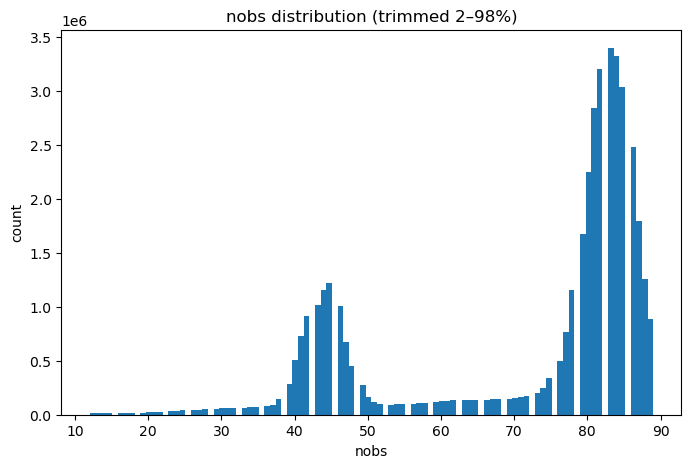

In [32]:
#nobs is still being horrible
import numpy as np
import rasterio
import matplotlib.pyplot as plt

#path = Path(r"C:\NCA_DATA\S2_Harmonics_vrt\S2SR_Harmonics_2018_4th.vrt")
path = r"C:\NCA_DATA\S2_Harmonics_vrt\S2SR_Harmonics_2025_4th_amp_phase_masked.tif"
with rasterio.open(path) as src:
    nobs = src.read(151)

vals = nobs[np.isfinite(nobs)]

print("min:", vals.min())
print("max:", vals.max())
print("mean:", vals.mean())
print("std:", vals.std())

p2, p98 = np.percentile(vals, [2, 98])

plt.figure(figsize=(8,5))
plt.hist(vals[(vals > p2) & (vals < p98)], bins=100)
plt.title("nobs distribution (trimmed 2–98%)")
plt.xlabel("nobs")
plt.ylabel("count")
plt.show()

In [16]:
from pathlib import Path
import re
import imageio.v2 as imageio
import numpy as np

# ============================================================
# SETTINGS
# ============================================================
fig_root = Path(r"C:\NCA_DATA\Figures")
product_folder = "Phase"   # "Amplitude", "Phase", "Intercept"
out_dir = fig_root / "GIFs" / product_folder
out_dir.mkdir(parents=True, exist_ok=True)

years = range(2018, 2026)

# GIF timing controls (robust)
frame_duration = 0.5   # seconds per frame
repeat_factor = 6      # duplicate each frame to slow playback

# ============================================================
# HELPERS
# ============================================================
def normalize_stem(stem):
    return re.sub(r"^\d{4}_", "", stem)

def ensure_rgb_or_rgba(arr):
    if arr.ndim == 2:
        return np.stack([arr, arr, arr], axis=-1)
    if arr.ndim == 3 and arr.shape[2] in (3, 4):
        return arr
    raise ValueError(f"Unsupported image shape: {arr.shape}")

def pad_to_common_shape(images, pad_value=255):
    images = [ensure_rgb_or_rgba(im) for im in images]

    max_h = max(im.shape[0] for im in images)
    max_w = max(im.shape[1] for im in images)
    max_c = max(im.shape[2] for im in images)

    padded = []
    for im in images:
        h, w, c = im.shape

        if c < max_c:
            if c == 3 and max_c == 4:
                alpha = np.full((h, w, 1), 255, dtype=im.dtype)
                im = np.concatenate([im, alpha], axis=2)

        canvas = np.full((max_h, max_w, max_c), pad_value, dtype=im.dtype)

        y0 = (max_h - h) // 2
        x0 = (max_w - w) // 2
        canvas[y0:y0+h, x0:x0+w, :] = im

        padded.append(canvas)

    return padded

# ============================================================
# COLLECT FILES
# ============================================================
groups = {}
# groups[normalized_name] = [(year, path), ...]

for year in years:
    year_dir = fig_root / str(year) / product_folder

    if not year_dir.exists():
        print(f"Missing folder: {year_dir}")
        continue

    for png in year_dir.glob("*.png"):
        norm_name = normalize_stem(png.stem)
        groups.setdefault(norm_name, []).append((year, png))

# ============================================================
# WRITE GIFS
# ============================================================
for norm_name, items in sorted(groups.items()):
    items = sorted(items, key=lambda x: x[0])
    found_years = [yr for yr, _ in items]

    print(f"{norm_name}: years found = {found_years}")

    if len(items) < 2:
        print(f"Skipped {norm_name}: fewer than 2 frames")
        continue

    # read images
    raw_frames = [imageio.imread(path) for _, path in items]

    # enforce same shape
    frames = pad_to_common_shape(raw_frames, pad_value=255)

    # ------------------------------------------------------------
    # SLOW DOWN (frame duplication)
    # ------------------------------------------------------------
    expanded_frames = []
    for f in frames:
        expanded_frames.extend([f] * repeat_factor)

    out_gif = out_dir / f"{norm_name}_{years.start}_{years.stop - 1}.gif"

    imageio.mimsave(
        out_gif,
        expanded_frames,
        duration=frame_duration,
        loop=0
    )

    print(f"Saved GIF: {out_gif}")

print("Done.")

B11_Phase_Histogram_(phi1): years found = [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Saved GIF: C:\NCA_DATA\Figures\GIFs\Phase\B11_Phase_Histogram_(phi1)_2018_2025.gif
B11_Phase_Map_(phi1): years found = [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Saved GIF: C:\NCA_DATA\Figures\GIFs\Phase\B11_Phase_Map_(phi1)_2018_2025.gif
B12_Phase_Histogram_(phi1): years found = [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Saved GIF: C:\NCA_DATA\Figures\GIFs\Phase\B12_Phase_Histogram_(phi1)_2018_2025.gif
B12_Phase_Map_(phi1): years found = [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Saved GIF: C:\NCA_DATA\Figures\GIFs\Phase\B12_Phase_Map_(phi1)_2018_2025.gif
B2_Phase_Histogram_(phi1): years found = [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Saved GIF: C:\NCA_DATA\Figures\GIFs\Phase\B2_Phase_Histogram_(phi1)_2018_2025.gif
B2_Phase_Map_(phi1): years found = [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Saved GIF: C:\NCA_DATA\Figures\GIFs\Phase\B2_Phase_Map_(phi1)_2018_2025.

In [ ]:
#nobs is being horrible again
import numpy as np
import rasterio

with rasterio.open(path) as src:
    nobs = src.read(135)

print("percent <= 0:", np.mean(nobs <= 0))
print("percent > 0:", np.mean(nobs > 0))

with rasterio.open(in_raster) as src:
    nobs = src.read(145)
    print(nobs.min(), nobs.max())

percent <= 0: 0.8295283462617821
percent > 0: 0.170471653738218
-731180.4 47828.773


In [ ]:
#%valid pixels?

import numpy as np
import pandas as pd
import rasterio

stack = r"C:\NCA_DATA\S2_Harmonics_vrt\S2SR_Harmonics_2018_4th_amp_phase.tif"

reflectance_vars = {"B2","B3","B4","B5","B6","B7","B8","B8A","B9","B11","B12"}
index_vars = {"NDVI","NDMI","NDRE","BSI","NBR2"}

def classify_band(desc):
    if desc == "nobs":
        return "nobs", None, None
    parts = desc.split("_", 1)
    metric = parts[0]
    var = parts[1]
    return metric, var, ("reflectance" if var in reflectance_vars else "index")

rows = []

with rasterio.open(stack) as src:
    nodata = src.nodata
    descs = src.descriptions
    
    for i, desc in enumerate(descs, start=1):
        arr = src.read(i).astype("float32")
        
        valid = np.isfinite(arr)
        if nodata is not None:
            valid &= (arr != nodata)
        
        vals = arr[valid]
        if vals.size == 0:
            rows.append({
                "band": i,
                "name": desc,
                "n_valid": 0,
                "min": np.nan,
                "max": np.nan,
                "mean": np.nan,
                "pct_flagged": np.nan,
            })
            continue
        
        metric, var, vtype = classify_band(desc)
        
        flagged = np.zeros(vals.shape, dtype=bool)
        
        if desc == "nobs":
            flagged |= (vals < 0)
        elif metric == "phi1" or metric == "phi2" or metric == "phi3" or metric == "phi4":
            flagged |= (vals < -np.pi) | (vals > np.pi)
        elif metric.startswith("A"):
            if vtype == "reflectance":
                flagged |= (vals < 0) | (vals > 1.0)
            else:
                flagged |= (vals < 0) | (vals > 2.0)
        elif metric == "beta0":
            if vtype == "reflectance":
                flagged |= (vals < -0.1) | (vals > 1.0)
            else:
                flagged |= (vals < -1.2) | (vals > 1.2)
        elif metric == "RMSE":
            if vtype == "reflectance":
                flagged |= (vals < 0) | (vals > 1.0)
            else:
                flagged |= (vals < 0) | (vals > 2.0)
        
        rows.append({
            "band": i,
            "name": desc,
            "n_valid": int(vals.size),
            "min": float(np.nanmin(vals)),
            "max": float(np.nanmax(vals)),
            "mean": float(np.nanmean(vals)),
            "pct_flagged": float(flagged.mean() * 100.0),
        })

qa = pd.DataFrame(rows)
print(qa.sort_values("pct_flagged", ascending=False).head(30))

valid min: 6.25174e-07
valid max: 99.90909
valid mean: 0.27084497


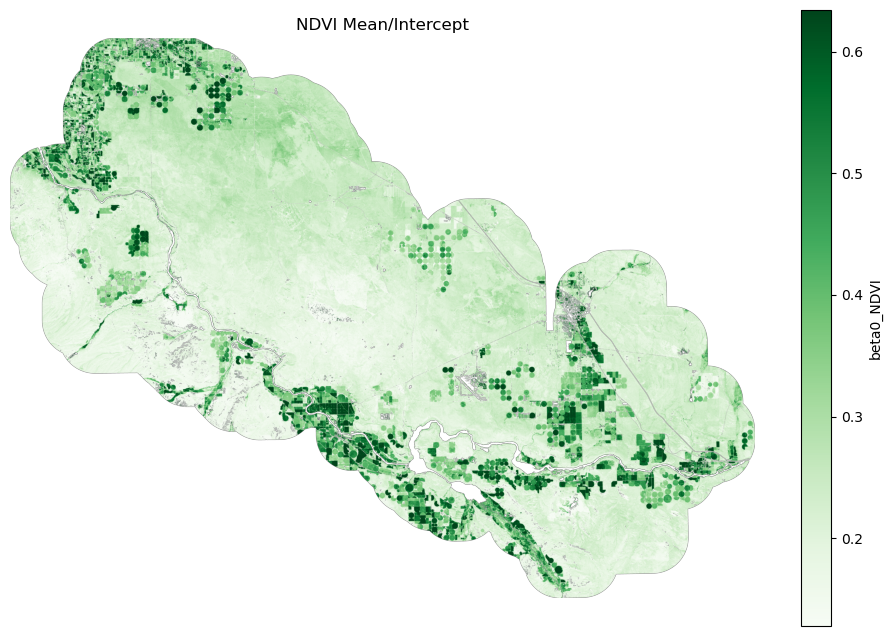

In [16]:
#Intercept visualizations
import numpy as np
import rasterio
import matplotlib.pyplot as plt

path = r"C:\NCA_DATA\S2_Harmonics_vrt\S2SR_Harmonics_2025_4th_amp_phase.tif"
band_name = "beta0_NDVI"#"A1_B4" #A1_B8, A1_NDVI, A1_NDMI

with rasterio.open(path) as src:
    idx = src.descriptions.index(band_name) + 1
    arr = src.read(idx).astype("float32")

# mask invalid values
mask = np.isfinite(arr) & (arr >= 0) & (arr <= 100)
vals = arr[mask]

print("valid min:", vals.min())
print("valid max:", vals.max())
print("valid mean:", vals.mean())

# compute percentiles only on valid values
p2, p98 = np.percentile(vals, [2, 98])

# build masked array for plotting
plot_arr = np.ma.masked_where(~mask, arr)

plt.figure(figsize=(12,8))
plt.imshow(plot_arr, cmap="Greens", vmin=p2, vmax=p98)
plt.colorbar(label=band_name)
plt.title("NDVI Mean/Intercept") #f"{band_name} (masked >100, trimmed 2–98%)"
plt.axis("off")
plt.show()

valid min: 1.0904948e-05
valid max: 99.994354
valid mean: 0.116658345


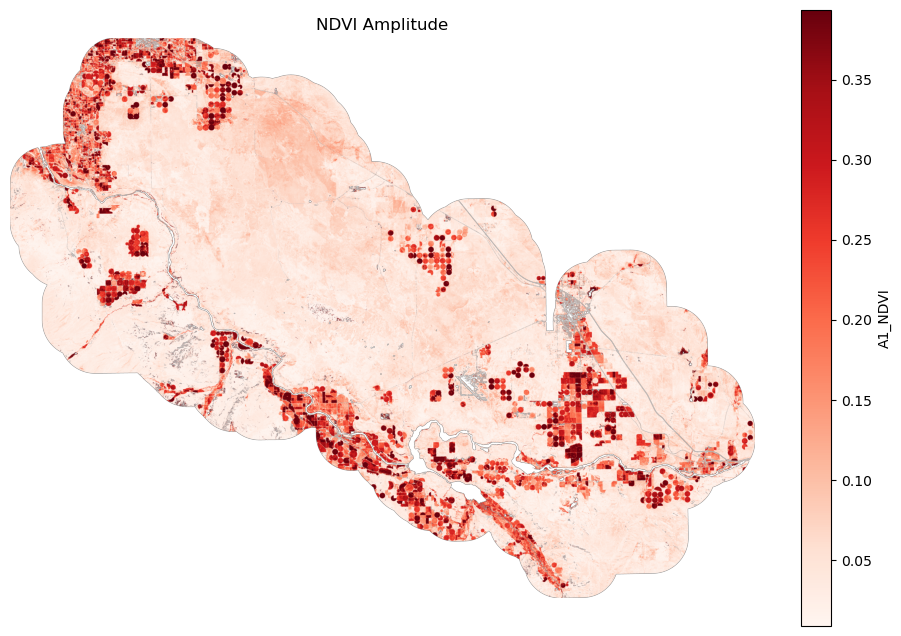

In [17]:
#Amplitude visualizations
import numpy as np
import rasterio
import matplotlib.pyplot as plt

path = r"C:\NCA_DATA\S2_Harmonics_vrt\S2SR_Harmonics_2025_4th_amp_phase.tif"
#path = out_raster
band_name = "A1_NDVI"#"A1_B4" #A1_B8, A1_NDVI, A1_NDMI

with rasterio.open(path) as src:
    idx = src.descriptions.index(band_name) + 1
    arr = src.read(idx).astype("float32")

# mask invalid values
mask = np.isfinite(arr) & (arr >= 0) & (arr <= 100)
vals = arr[mask]

print("valid min:", vals.min())
print("valid max:", vals.max())
print("valid mean:", vals.mean())

# compute percentiles only on valid values
p2, p98 = np.percentile(vals, [2, 98])

# build masked array for plotting
plot_arr = np.ma.masked_where(~mask, arr)

plt.figure(figsize=(12,8))
plt.imshow(plot_arr, cmap="Reds", vmin=p2, vmax=p98)
plt.colorbar(label=band_name)
plt.title("NDVI Amplitude") #f"{band_name} (masked >100, trimmed 2–98%)"
plt.axis("off")
plt.show()

min: -3.1415925
max: 3.141592
mean: 0.04899971
median: 0.39255622


C:\Users\scottfordham\AppData\Local\Temp\ipykernel_2632\1091600776.py:44: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


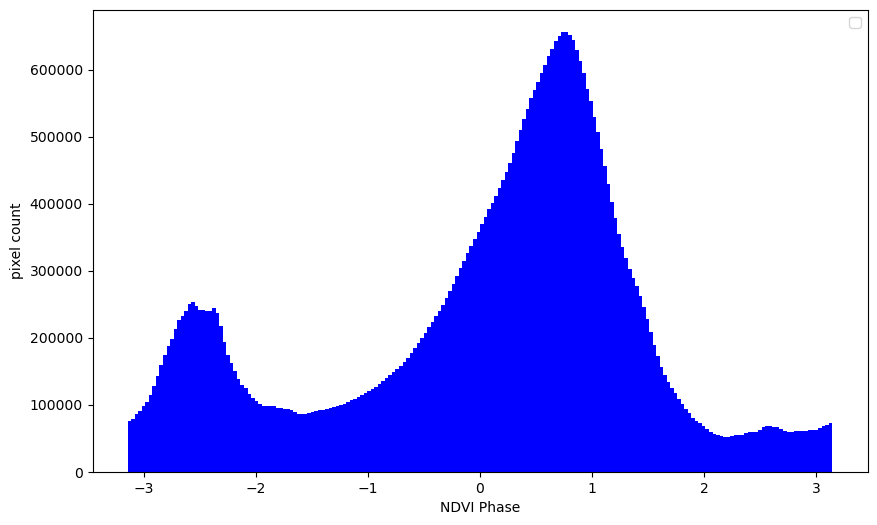

In [29]:
#A1_NDVI Histogram
import numpy as np
import rasterio
import matplotlib.pyplot as plt

path = out_raster

with rasterio.open(path) as src:
    A1 = src.read(src.descriptions.index("phi1_NDVI") + 1).astype("float32")

mask = (
    np.isfinite(A1) &
    (A1 >= -np.pi) &
    (A1 <= np.pi)
)

vals = A1[mask]

print("min:", vals.min())
print("max:", vals.max())
print("mean:", vals.mean())
print("median:", np.median(vals))

p1, p99 = np.percentile(vals, [1,99])

plt.figure(figsize=(10,6))

plt.hist(
    vals,
    bins=200,
    #range=(0,0.15),
    range=(-np.pi, np.pi),
    color="blue"
)

#plt.axvline(p1, linestyle="--", color="black", label="1st percentile")
#plt.axvline(p99, linestyle="--", color="black", label="99th percentile")

#plt.xlabel("RMSE NDVI (seasonal RMSE)")
plt.xlabel("NDVI Phase")
plt.ylabel("pixel count")
#plt.title("Histogram of NDVI Seasonal RMSE")

plt.legend()
plt.show()

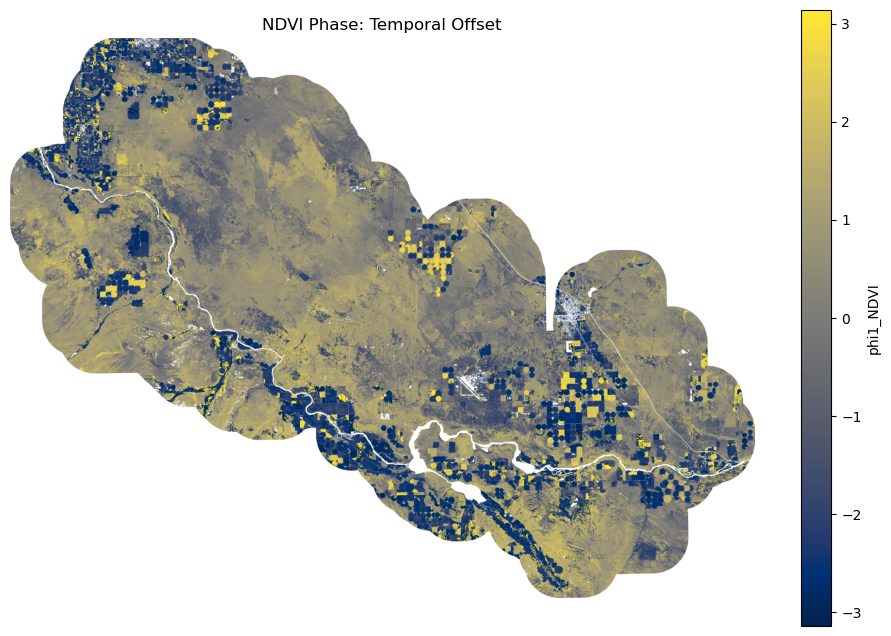

In [30]:
# Phi visualization
import numpy as np
import rasterio
import matplotlib.pyplot as plt

path = out_raster

with rasterio.open(path) as src:

    phi = src.read(src.descriptions.index("phi1_NDVI") + 1).astype("float32")
    A1  = src.read(src.descriptions.index("A1_NDVI") + 1).astype("float32")

# build amplitude-based mask
mask = (
    np.isfinite(A1) &
    (A1 > 0) &
    (A1 < 1)
)

# apply mask to phase
plot_arr = np.ma.masked_where(~mask, phi)

# set masked color
cmap = plt.cm.cividis.copy()
cmap.set_bad("white")

plt.figure(figsize=(12,8))
plt.imshow(plot_arr, cmap=cmap, vmin=-np.pi, vmax=np.pi)
plt.colorbar(label="phi1_NDVI")
plt.title("NDVI Phase: Temporal Offset")
plt.axis("off")
plt.show()

In [31]:
print(out_raster)

C:\NCA_DATA\S2_Harmonics_vrt\S2SR_Harmonics_2025_4th_amp_phase_masked.tif


valid min: 0.0
valid max: 0.2202512
valid mean: 0.02304414


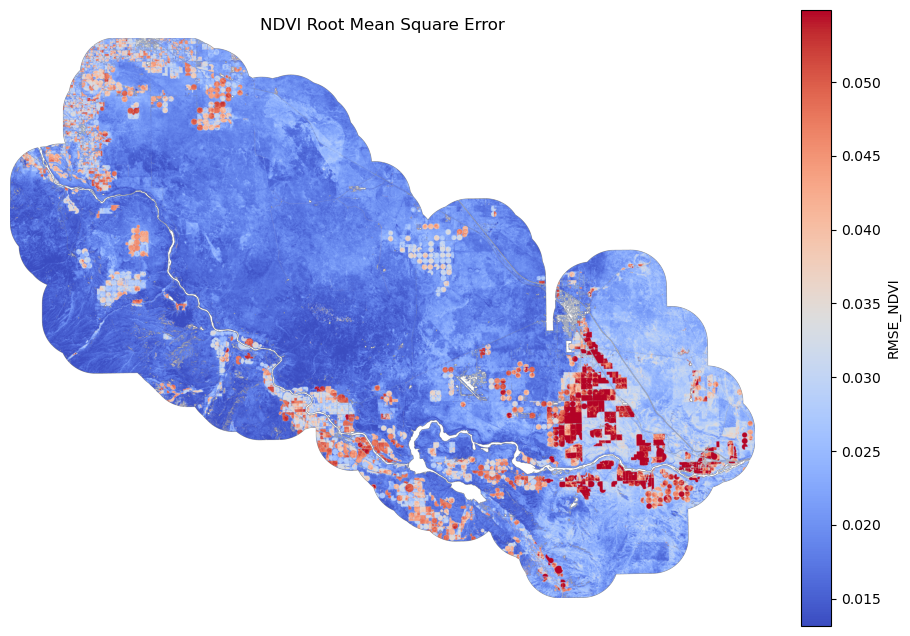

In [48]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt

path = out_raster
band_name = "RMSE_NDVI"   # swap as needed

with rasterio.open(path) as src:
    idx = src.descriptions.index(band_name) + 1
    arr = src.read(idx).astype("float32")

# mask invalid values and absurd artifacts
mask = np.isfinite(arr) & (arr >= 0)
vals = arr[mask]

print("valid min:", vals.min())
print("valid max:", vals.max())
print("valid mean:", vals.mean())

p2, p98 = np.percentile(vals, [2, 98])
plot_arr = np.ma.masked_where(~mask, arr)

plt.figure(figsize=(12, 8))
plt.imshow(plot_arr, cmap="coolwarm", vmin=p2, vmax=p98)
plt.colorbar(label=band_name)
plt.title("NDVI Root Mean Square Error")
plt.axis("off")
plt.show()

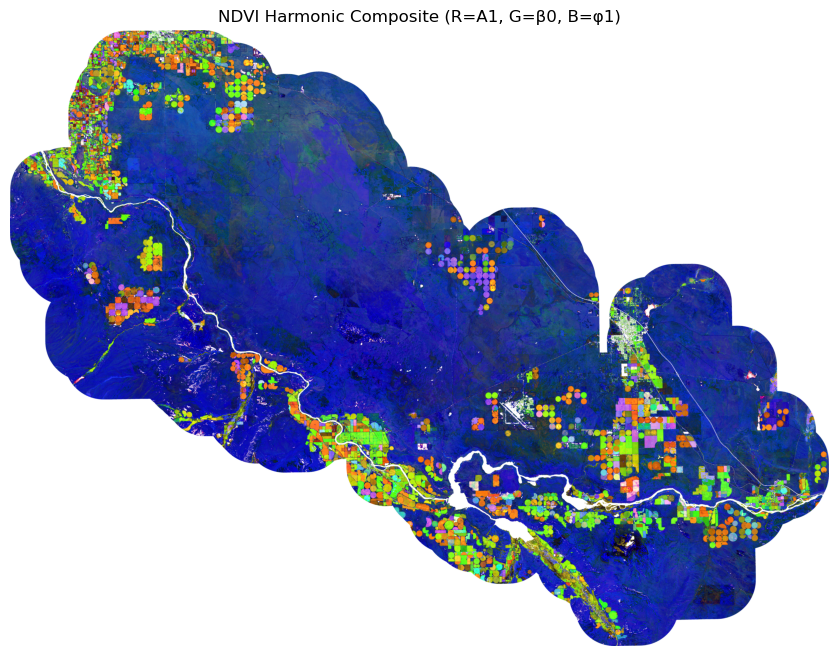

In [44]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt

path = out_raster

def robust_scale(arr, mask, pmin=2, pmax=98):
    vals = arr[mask]
    lo, hi = np.percentile(vals, [pmin, pmax])
    out = (arr - lo) / (hi - lo)
    return np.clip(out, 0, 1)

with rasterio.open(path) as src:
    beta0 = src.read(src.descriptions.index("beta0_NDVI") + 1).astype("float32")
    A1    = src.read(src.descriptions.index("A1_NDVI") + 1).astype("float32")
    phi1  = src.read(src.descriptions.index("phi1_NDVI") + 1).astype("float32")

# --------------------------------------------------
# PHYSICAL FILTERS
# --------------------------------------------------

mask = (
    np.isfinite(beta0) &
    np.isfinite(A1) &
    np.isfinite(phi1) &
    (A1 >= 0) & (A1 <= 10) &     # amplitude constraint
    (beta0 >= -1) & (beta0 <= 1) # NDVI physical range
)

# --------------------------------------------------
# SCALING
# --------------------------------------------------

R = robust_scale(A1, mask)
G = robust_scale(beta0, mask)

# phase normalization for phi [-pi, pi] → [0,1]
B = (phi1 + np.pi) / (2 * np.pi)
B = np.clip(B, 0, 1)
#B = robust_scale(phi1, mask)

rgb = np.dstack([R, G, B])
rgb[~mask] = 1.0

plt.figure(figsize=(12,8))
plt.imshow(rgb)
plt.title("NDVI Harmonic Composite (R=A1, G=β0, B=φ1)")
plt.axis("off")
plt.show()

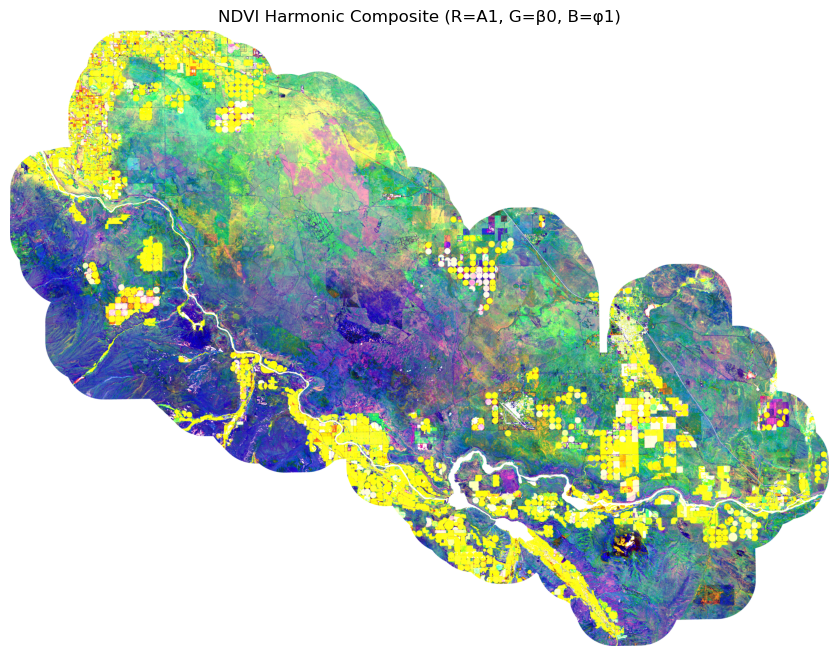

In [47]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt

path = out_raster

def robust_scale(arr, stretch_mask, pmin=2, pmax=98):
    vals = arr[stretch_mask]
    lo, hi = np.percentile(vals, [pmin, pmax])

    # guard against degenerate ranges
    if hi <= lo:
        out = np.zeros_like(arr, dtype="float32")
    else:
        out = (arr - lo) / (hi - lo)

    return np.clip(out, 0, 1)

with rasterio.open(path) as src:
    beta0 = src.read(src.descriptions.index("beta0_NDVI") + 1).astype("float32")
    A1    = src.read(src.descriptions.index("A1_NDVI") + 1).astype("float32")
    phi1  = src.read(src.descriptions.index("phi1_NDVI") + 1).astype("float32")

# --------------------------------------------------
# DISPLAY MASK: physically valid pixels to show
# --------------------------------------------------

mask = (
    np.isfinite(beta0) &
    np.isfinite(A1) &
    np.isfinite(phi1) &
    (A1 >= 0) & (A1 <= 10) &
    (beta0 >= -1) & (beta0 <= 1)
)

# --------------------------------------------------
# AGRICULTURE-EXCLUSION MASK FOR STRETCH ONLY
# --------------------------------------------------
# Idea:
# ag pixels tend to be unusually high in both greenness (beta0)
# and seasonal amplitude (A1), so remove the upper joint tail
# from the percentile calculation.

A1_q   = np.percentile(A1[mask], 75)
beta_q = np.percentile(beta0[mask], 75)

ag_mask = mask & (A1 > A1_q) & (beta0 > beta_q)

# stretch mask excludes agriculture-like extremes,
# but those pixels will still be displayed later
stretch_mask = mask & (~ag_mask)

# --------------------------------------------------
# SCALING
# --------------------------------------------------

R = robust_scale(A1, stretch_mask, pmin=2, pmax=98)
G = robust_scale(beta0, stretch_mask, pmin=2, pmax=98)

# phase stays on its natural circular normalization
B = (phi1 + np.pi) / (2 * np.pi)
B = np.clip(B, 0, 1)

rgb = np.dstack([R, G, B])
rgb[~mask] = 1.0

plt.figure(figsize=(12, 8))
plt.imshow(rgb)
plt.title("NDVI Harmonic Composite (R=A1, G=β0, B=φ1)")
plt.axis("off")
plt.show()

A1 range: 6.157589e-05 0.4997784
RMSE range: 0.0060446924 0.07005113


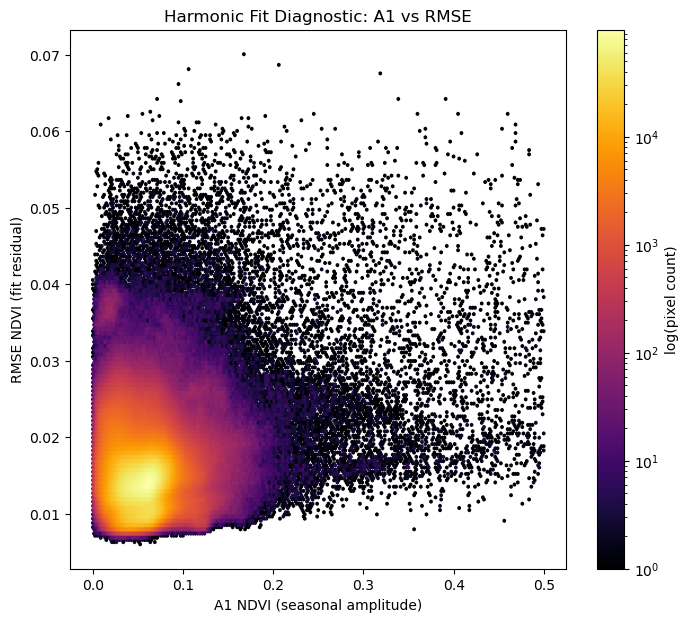

In [38]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt

path = out_raster

with rasterio.open(path) as src:
    A1 = src.read(src.descriptions.index("A1_NDVI") + 1).astype("float32")
    RMSE = src.read(src.descriptions.index("RMSE_NDVI") + 1).astype("float32")

# validity mask
mask = (
    np.isfinite(A1) &
    np.isfinite(RMSE) &
    (A1 >= 0) & (A1 <= 0.5) &
    (RMSE >= 0) & (RMSE <= 1)
)

A1v = A1[mask]
RMSEv = RMSE[mask]

print("A1 range:", A1v.min(), A1v.max())
print("RMSE range:", RMSEv.min(), RMSEv.max())

plt.figure(figsize=(8,7))

plt.hexbin(
    A1v,
    RMSEv,
    gridsize=200,
    bins="log",
    cmap="inferno"
)

plt.xlabel("A1 NDVI (seasonal amplitude)")
plt.ylabel("RMSE NDVI (fit residual)")
plt.title("Harmonic Fit Diagnostic: A1 vs RMSE")

cb = plt.colorbar()
cb.set_label("log(pixel count)")

plt.show()

beta0 range: -0.99603057 0.9996694
A1 range: 6.157589e-05 0.4997784


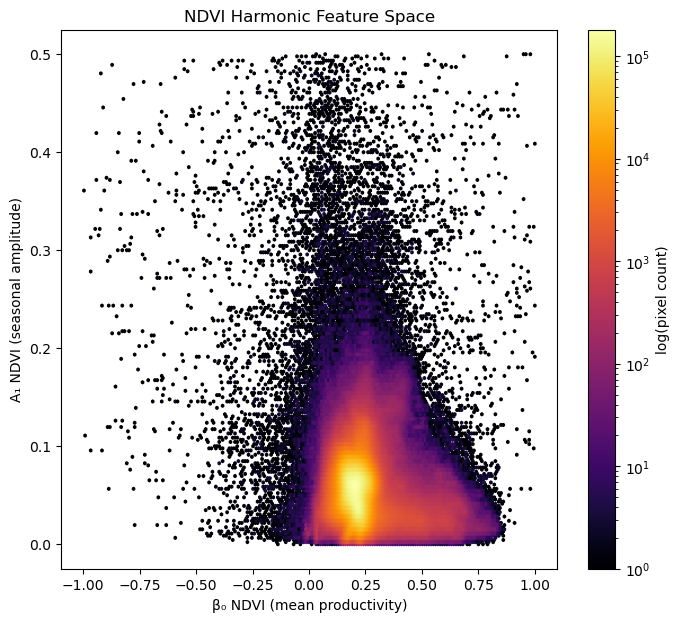

In [39]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt

path = out_raster

with rasterio.open(path) as src:
    beta0 = src.read(src.descriptions.index("beta0_NDVI") + 1).astype("float32")
    A1 = src.read(src.descriptions.index("A1_NDVI") + 1).astype("float32")

# --------------------------------------------------
# PHYSICAL FILTERS
# --------------------------------------------------

mask = (
    np.isfinite(beta0) &
    np.isfinite(A1) &
    (beta0 >= -1) & (beta0 <= 1) &   # NDVI physical range
    (A1 >= 0) & (A1 <= 0.5)           # amplitude sanity bound
)

beta0v = beta0[mask]
A1v = A1[mask]

print("beta0 range:", beta0v.min(), beta0v.max())
print("A1 range:", A1v.min(), A1v.max())

# --------------------------------------------------
# HEXBIN
# --------------------------------------------------

plt.figure(figsize=(8,7))

hb = plt.hexbin(
    beta0v,
    A1v,
    gridsize=200,
    bins="log",
    cmap="inferno"
)

plt.xlabel("β₀ NDVI (mean productivity)")
plt.ylabel("A₁ NDVI (seasonal amplitude)")
plt.title("NDVI Harmonic Feature Space")

cb = plt.colorbar(hb)
cb.set_label("log(pixel count)")

plt.show()